
=== EDA Summary (Mean, Std, Min, Max, Range) ===
                mean      std      min       max     range
dissolvedo2    95.06    38.17     0.00    130.69    130.69
orp         -3601.36  1891.22 -7460.00   1097.00   8557.00
ph              5.12     1.51     1.36     10.89      9.53
tds          1690.33   808.95     0.00   2147.42   2147.42
temp           28.03     0.65    27.44     35.81      8.37
turbidity       0.61     1.64     0.00      5.00      5.00
bga          1413.40  4471.96     0.00  29599.45  29599.45
chlorophyll   189.73    71.48     0.00    294.50    294.50

=== Correlation Matrix ===
             dissolvedo2   orp    ph   tds  temp  turbidity   bga  chlorophyll
dissolvedo2         1.00  0.08  0.01  0.52 -0.19       0.09 -0.14         0.10
orp                 0.08  1.00  0.26 -0.37  0.08       0.42  0.07        -0.02
ph                  0.01  0.26  1.00  0.19  0.12      -0.43 -0.38         0.26
tds                 0.52 -0.37  0.19  1.00  0.05      -0.55 -0.13        -0

/tmp/ipython-input-2683321826.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[c].dropna().values for c in df.columns],


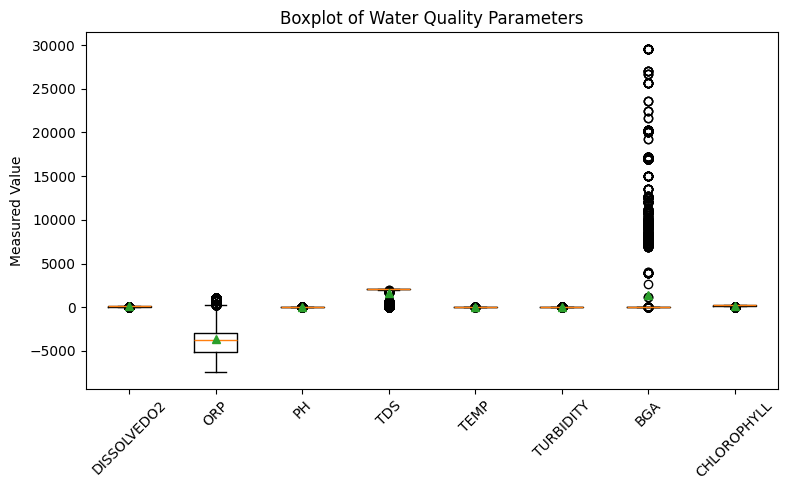

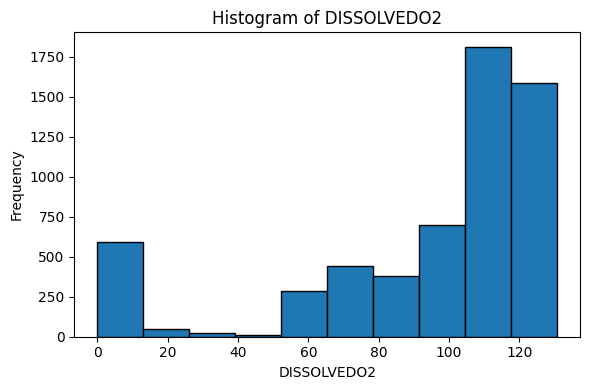

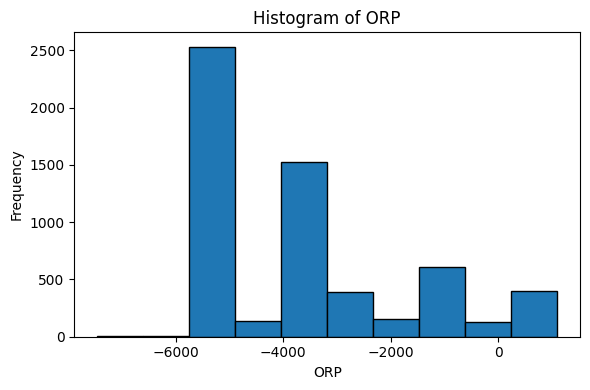

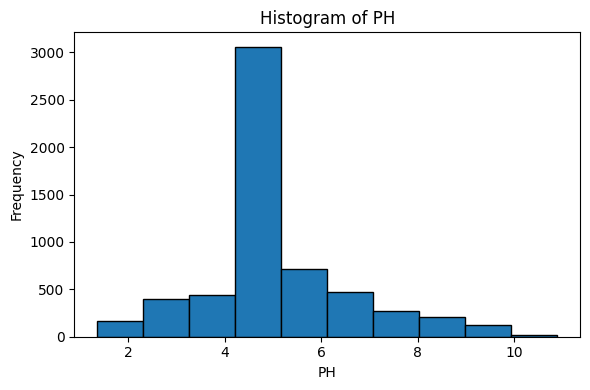

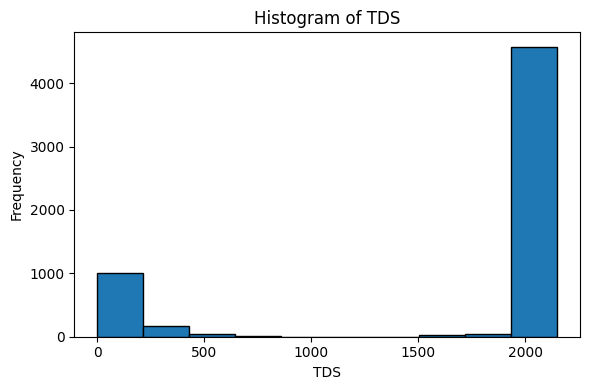

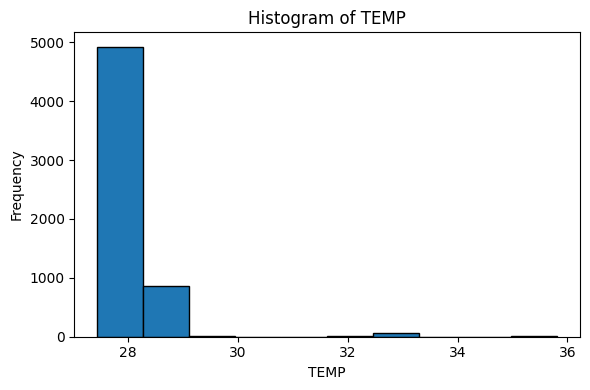

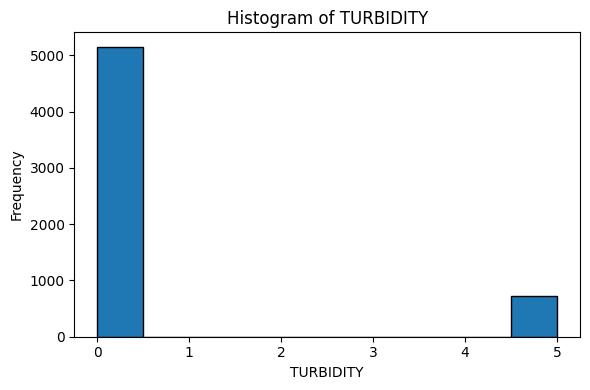

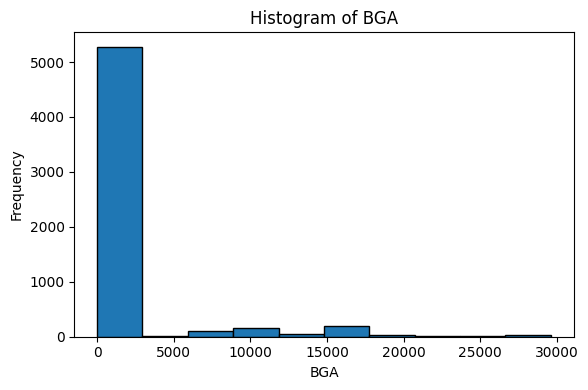

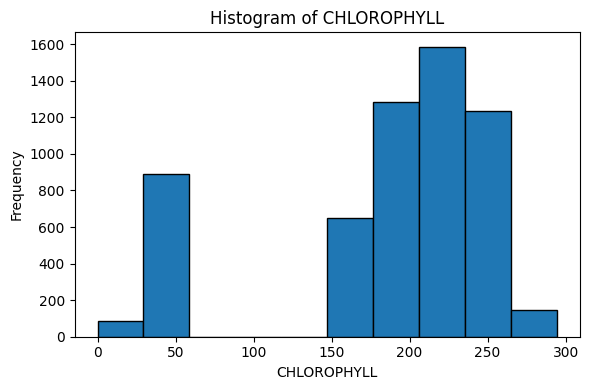

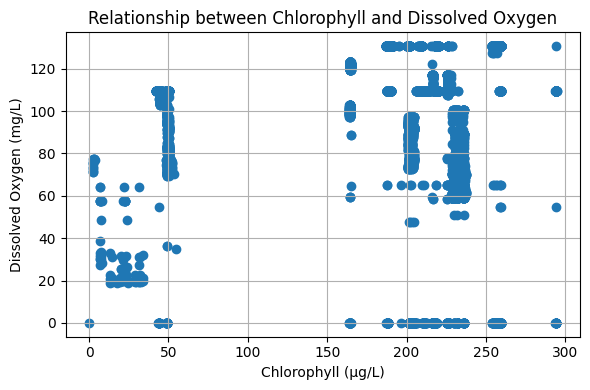

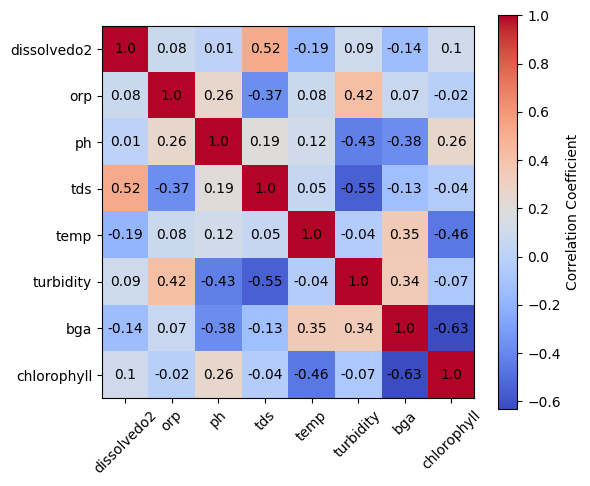

In [ ]:
# ============================
# Simple EDA for Aquatic Explorer Dataset
# ============================

import pandas as pd
import matplotlib.pyplot as plt

# ---- Step 1: Load dataset ----
df = pd.read_csv("Sensor_data_premonsoon.csv")   # change path if needed
df.columns = [c.strip().lower() for c in df.columns]

# ---- Step 2: Select numeric columns for EDA ----
cols = ['dissolvedo2', 'orp','ph', 'tds', 'temp', 'turbidity', 'bga', 'chlorophyll']
df = df[[c for c in cols if c in df.columns]]

# ---- Step 3: Basic summary statistics ----
print("\n=== EDA Summary (Mean, Std, Min, Max, Range) ===")
eda_summary = df.describe().T[['mean', 'std', 'min', 'max']].round(2)
eda_summary['range'] = (eda_summary['max'] - eda_summary['min']).round(2)
print(eda_summary)

# ---- Step 4: Correlation matrix ----
print("\n=== Correlation Matrix ===")
corr_matrix = df.corr().round(2)
print(corr_matrix)

# ---- Step 5: Boxplot of all parameters ----
plt.figure(figsize=(8,5))
plt.boxplot([df[c].dropna().values for c in df.columns],
            labels=[c.upper() for c in df.columns],
            showmeans=True)
plt.title("Boxplot of Water Quality Parameters")
plt.ylabel("Measured Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- Step 6: Histogram of each parameter ----
for c in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[c].dropna(), bins=10, edgecolor='black')
    plt.title(f"Histogram of {c.upper()}")
    plt.xlabel(c.upper())
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# ---- Step 7: Scatter plot (DO vs Chlorophyll) ----
if 'chlorophyll' in df.columns and 'dissolvedo2' in df.columns:
    plt.figure(figsize=(6,4))
    plt.scatter(df['chlorophyll'], df['dissolvedo2'])
    plt.title("Relationship between Chlorophyll and Dissolved Oxygen")
    plt.xlabel("Chlorophyll (µg/L)")
    plt.ylabel("Dissolved Oxygen (mg/L)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---- Step 8: Correlation Heatmap ----
plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
#plt.title("Correlation Heatmap of Parameters")
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, str(corr_matrix.iloc[i, j]), ha='center', va='center', color='black')
plt.tight_layout()
plt.show()


**VP-CV**

Fitted a,b,c: (2.1696788174992956, 0.32157046204194517, 0.0004987279647299602)


,time_idx,state,Ti,action
0,0,1,NaN,wait
1,1,1,NaN,wait
2,2,1,NaN,wait
3,3,1,NaN,wait
4,4,2,1.791382,warning_switch
5,5,2,NaN,wait
6,6,2,1.777513,warning_switch
7,7,2,1.796981,warning_switch
8,8,2,1.800779,warning_switch
9,9,2,1.737467,warning_switch


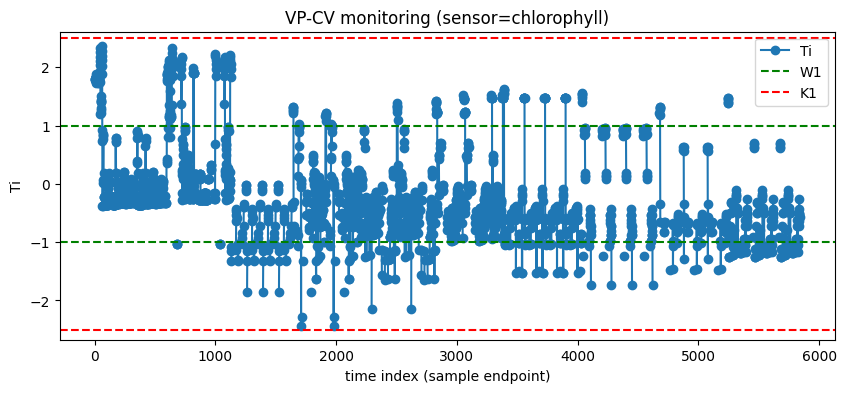

In [ ]:
# Colab-ready simplified VP-CV monitor
# Assumes `df` loaded and numeric sensor column e.g. 'dissolvedo2'
# pip installs (uncomment in Colab if needed)
# !pip install scipy numpy pandas matplotlib

import numpy as np
import pandas as pd
from scipy.stats import t, norm
import matplotlib.pyplot as plt

# --- helper: sample CV on sliding windows
def sliding_sample_cv(series, window):
    X = series.values
    gammas = []
    indices = []
    for i in range(len(X) - window + 1):
        block = X[i:i+window]
        mu = block.mean()
        s = block.std(ddof=1)
        if mu == 0:
            gammas.append(np.nan)
        else:
            gammas.append(s/mu)
        indices.append(i+window-1)  # index of sample endpoint
    return np.array(gammas), np.array(indices)

# --- helper: fit 3-parameter lognormal via quantiles r, 0.5, 1-r
def fit_3param_lognormal_from_quantiles(gamma_samples, n, gamma0_est=None, r=0.05):
    # gamma_samples: historical/simulated gamma distribution to get quantiles
    # n: sample size (used in paper for theoretical quantiles; here we use empirical)
    # We'll use empirical quantiles of gamma_samples (practical approach)
    xr = np.nanquantile(gamma_samples, r)
    x05 = np.nanquantile(gamma_samples, 0.5)
    x1r = np.nanquantile(gamma_samples, 1 - r)
    # Careful: need xr < x05 < x1r
    if not (xr < x05 < x1r):
        return None  # fitting failed
    # Paper uses F_N^{-1}(r), standard normal quantile
    z_r = norm.ppf(r)
    # compute b,a,c per paper (Eqs. 5-7)
    num = x05 - xr
    den = x1r - x05
    if den <= 0 or num <= 0:
        return None
    b = z_r / np.log(num/den)
    # Avoid division by zero / invalid
    a = -b * np.log((x05 - xr) / (1 - np.exp(z_r / b)))
    c = x05 - np.exp(-a / b)
    return float(a), float(b), float(c)

# --- transform gamma to Ti
def gamma_to_T(gamma, a,b,c):
    # guard: gamma must be > c
    return a + b * np.log(gamma - c)

# --- Example usage for one sensor column
sensor_col = 'chlorophyll'   # change to sensor of interest
df_sensor = df[sensor_col].dropna().reset_index(drop=True)

# choose sliding window n (sample size)
n1 = 5   # relaxed sample size (practical)
n2 = 7   # tight sample size
window_for_historical = max(n1, n2) * 6  # gather some gamma samples for fitting

# compute historical gamma samples (for fitting a,b,c)
gammas_hist, idx_hist = sliding_sample_cv(df_sensor, window_for_historical)
# remove NaNs
gammas_hist = gammas_hist[~np.isnan(gammas_hist)]

fit = fit_3param_lognormal_from_quantiles(gammas_hist, window_for_historical, r=0.05)
if fit is None:
    print("3-param fit failed; try using larger historical window or empirical transform.")
else:
    a,b,c = fit
    print("Fitted a,b,c:", (a,b,c))

    # sliding CV for the monitoring windows (use whichever window appropriate)
    gam1, idx1 = sliding_sample_cv(df_sensor, n1)
    gam2, idx2 = sliding_sample_cv(df_sensor, n2)

    # compute Ti sequences aligned to endpoints (we will monitor at each time step using latest available n)
    Ti1 = np.array([gamma_to_T(g, a,b,c) if (not np.isnan(g) and g>c) else np.nan for g in gam1])
    Ti2 = np.array([gamma_to_T(g, a,b,c) if (not np.isnan(g) and g>c) else np.nan for g in gam2])

    # Set VP thresholds (heuristic start)
    W1, K1 = 1.0, 2.5  # central (relaxed) limits
    W2, K2 = 0.8, 2.0  # warning (tight) limits (narrower)

    # We'll do a simple stateful VP loop: start in central (k=1)
    state = 1
    flags = []   # store (time_index, state, Ti_value, action)
    # iterate over time indexes; at time t we use the latest Ti computed with the currently chosen n
    max_t = max(idx1[-1] if len(idx1)>0 else 0, idx2[-1] if len(idx2)>0 else 0)
    for t in range(max_t+1):
        # pick Ti depending on state and availability
        if state == 1:
            # use Ti1 if available at time t (endpoint index)
            loc = np.where(idx1 == t)[0]
            Ti = Ti1[loc[0]] if len(loc)>0 else np.nan
            W,K = W1,K1
        else:
            loc = np.where(idx2 == t)[0]
            Ti = Ti2[loc[0]] if len(loc)>0 else np.nan
            W,K = W2,K2

        # Action: decide switch or flag
        if np.isnan(Ti):
            action = 'wait'
        else:
            if abs(Ti) <= W:
                action = 'central_keep'
                state = 1
            elif W < abs(Ti) <= K:
                action = 'warning_switch'
                state = 2
            else:
                action = 'out_of_control'
                # keep state as 2 (tight) or raise alarm as needed
                state = 2
        flags.append((t, state, Ti, action))

    # Convert flags to DataFrame for inspection
    flags_df = pd.DataFrame(flags, columns=['time_idx', 'state', 'Ti', 'action'])
    display(flags_df.head(30))

    # sample plot: Ti over time with regions
    times = [row[0] for row in flags]
    Ti_vals = [row[2] for row in flags]
    plt.figure(figsize=(10,4))
    plt.plot(times, Ti_vals, marker='o', label='Ti')
    plt.axhline(W1, color='green', linestyle='--', label='W1')
    plt.axhline(-W1, color='green', linestyle='--')
    plt.axhline(K1, color='red', linestyle='--', label='K1')
    plt.axhline(-K1, color='red', linestyle='--')
    plt.title(f"VP-CV monitoring (sensor={sensor_col})")
    plt.xlabel("time index (sample endpoint)")
    plt.ylabel("Ti")
    plt.legend()
    plt.show()


**ASSD + VP-CV for all sensors**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Columns: ['sample_id', 'lat', 'lon', 'dissolvedo2', 'orp', 'ph', 'tds', 'temp', 'time', 'turbidity', 'bga', 'bga_temp', 'chl_temp', 'chlorophyll']

[DISSOLVEDO2] ASSD stable index: 5 Variance reduction (%): -2573269.12


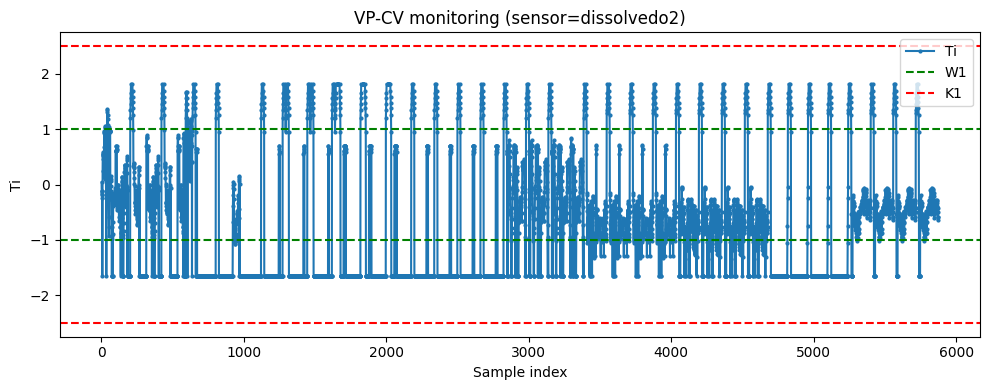

[DISSOLVEDO2] VP-CV out-of-control points: 0

[PH] ASSD stable index: 5 Variance reduction (%): nan


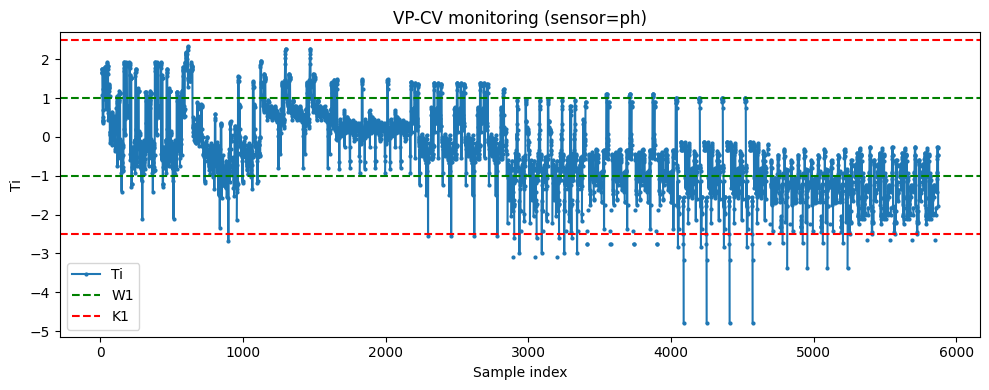

[PH] VP-CV out-of-control points: 179

[TDS] ASSD stable index: 6 Variance reduction (%): -242.13


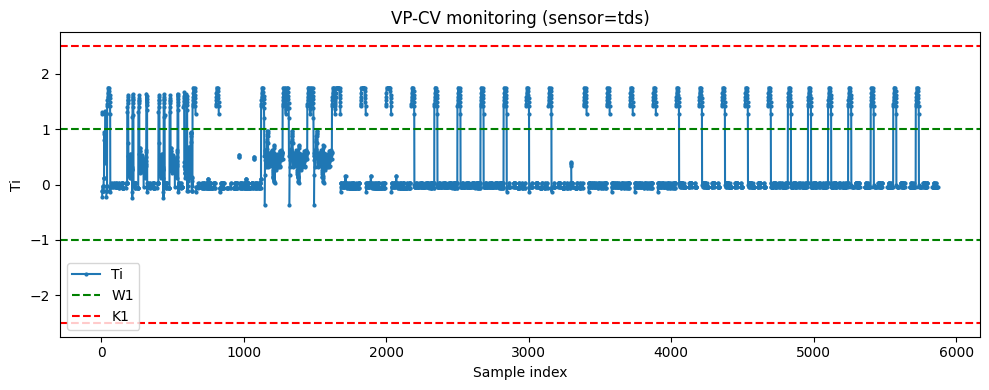

[TDS] VP-CV out-of-control points: 0

[TEMP] ASSD stable index: 5 Variance reduction (%): -5099.65


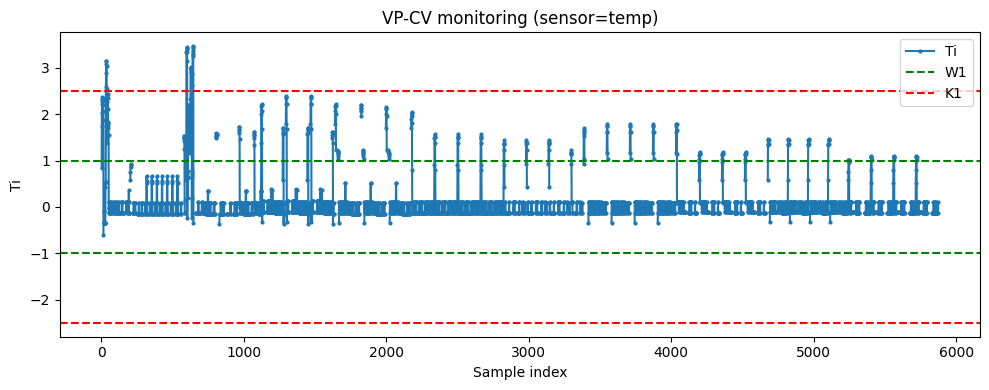

[TEMP] VP-CV out-of-control points: 79

[TURBIDITY] ASSD stable index: 5 Variance reduction (%): nan


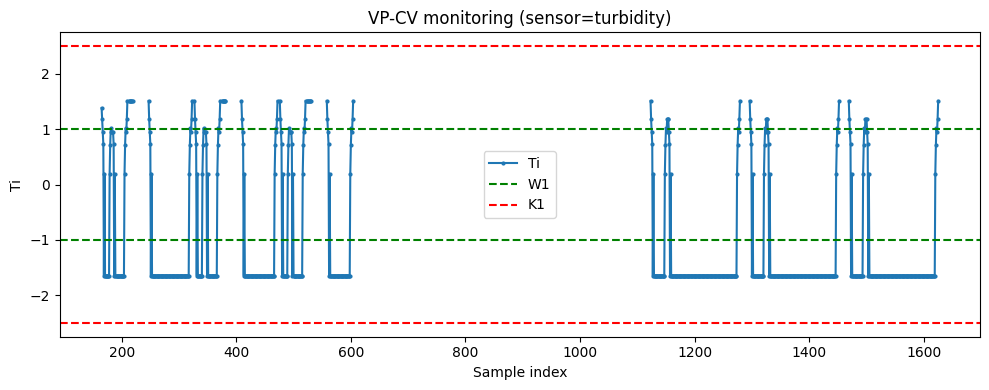

[TURBIDITY] VP-CV out-of-control points: 0

[ORP] ASSD stable index: 7 Variance reduction (%): -1.75


/tmp/ipython-input-2851636614.py:110: RuntimeWarning: invalid value encountered in log
  a = -b * np.log((x05 - xr) / (1 - np.exp(z_r / b)))


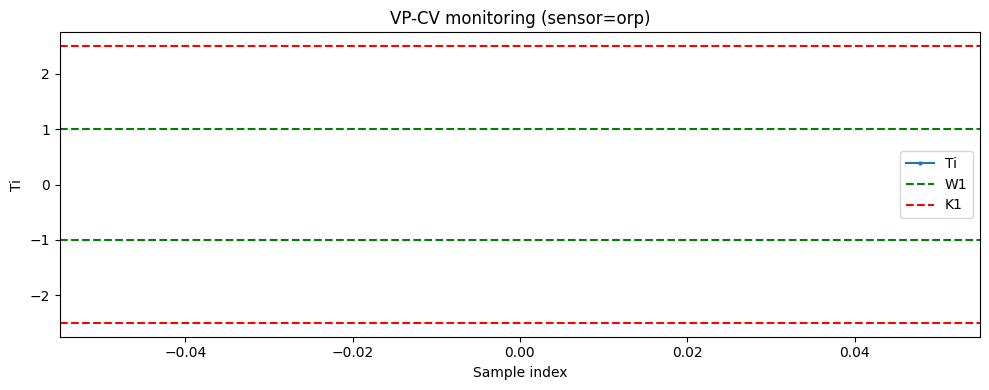

[ORP] VP-CV out-of-control points: 0

[BGA] ASSD stable index: 8 Variance reduction (%): -256.38


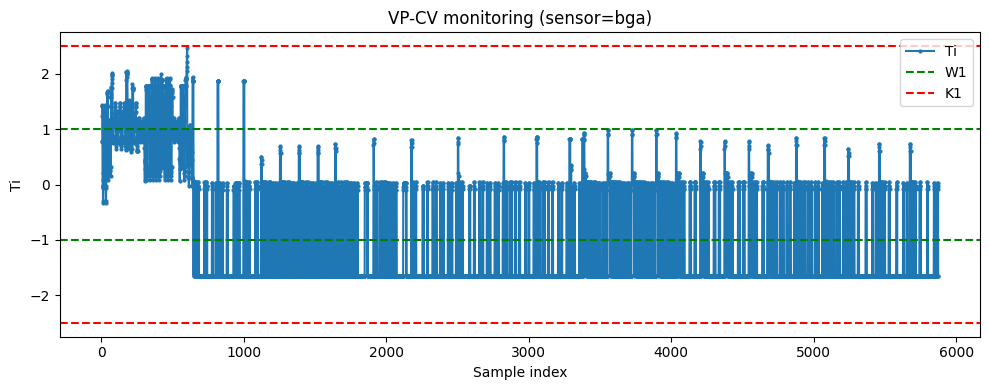

[BGA] VP-CV out-of-control points: 13

[CHLOROPHYLL] ASSD stable index: 5 Variance reduction (%): -14218.04


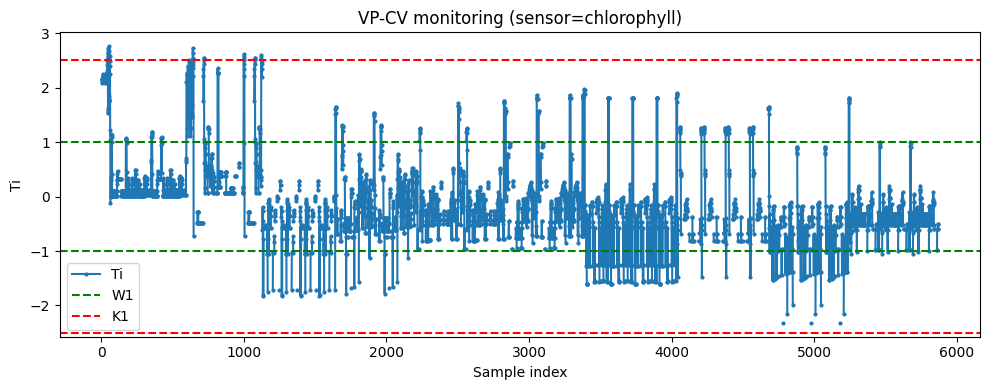

[CHLOROPHYLL] VP-CV out-of-control points: 118

=== Sensor Stability Summary (ASSD + VP-CV) ===
        sensor     mean      std    cv_%  assd_stable_index  \
0  dissolvedo2    95.06    38.17   40.15                  5   
1           ph     5.12     1.51   29.57                  5   
2          tds  1690.33   808.95   47.86                  6   
3         temp    28.03     0.65    2.32                  5   
4    turbidity     0.61     1.64  267.76                  5   
5          orp -3601.36  1891.22  -52.51                  7   
6          bga  1413.40  4471.96  316.40                  8   
7  chlorophyll   189.73    71.48   37.68                  5   

   assd_variance_reduction_%  vp_cv_out_of_control_count  
0                -2573269.12                           0  
1                        NaN                         179  
2                    -242.13                           0  
3                   -5099.65                          79  
4                        NaN             

In [ ]:
# ================================
# Aquatic Explorer – ASSD + VP-CV
# Google Colab Notebook Cell
# ================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# 3. Load dataset  (EDIT THIS PATH)
file_path = "/content/drive/MyDrive/Sensor_data_premonsoon.csv"
df = pd.read_csv(file_path)
df.columns = [c.strip().lower() for c in df.columns]
print("Columns:", df.columns.tolist())

# 4. List of sensors to analyze
sensors = ['dissolvedo2','ph','tds','temp','turbidity','orp','bga','chlorophyll']
sensors = [s for s in sensors if s in df.columns]  # keep only existing

# ======================================================
# PART A – ASSD (Adaptive Sensor Stabilization Detection)
# ======================================================

def assd_detect_stabilization(values, window=3, threshold_var=0.02, consecutive=3):
    """
    Adaptive Sensor Stabilization Detection on a *standardized* series.
    values: 1D numpy array (raw values)
    threshold_var: variance threshold on standardized signal
    returns: stable_index (int or None), variance_reduction_percent
    """
    x = values.astype(float)
    x = x[~np.isnan(x)]
    if len(x) < window + consecutive:
        return None, np.nan

    # Standardize
    z = (x - x.mean()) / (x.std(ddof=1) if x.std(ddof=1) != 0 else 1.0)

    stable_index = None
    stable_count = 0
    vars_ = []

    for i in range(window, len(z)):
        v = np.var(z[i-window:i])
        vars_.append(v)
        if v < threshold_var:
            stable_count += 1
            if stable_count >= consecutive and stable_index is None:
                stable_index = i
        else:
            stable_count = 0

    # Variance reduction before vs after stabilization (on standardized data)
    if stable_index is not None and stable_index < len(z):
        before = np.var(z[:stable_index]) if stable_index > 0 else np.nan
        after = np.var(z[stable_index:])
        if before and before > 0:
            reduction = (before - after) / before * 100
        else:
            reduction = np.nan
    else:
        reduction = np.nan

    return stable_index, round(reduction, 2)

# ======================================
# PART B – VP-CV (Variable-Parameter CV)
# ======================================

def sliding_sample_cv(series, window):
    x = series.values.astype(float)
    gammas = []
    idx = []
    for i in range(len(x) - window + 1):
        block = x[i:i+window]
        block = block[~np.isnan(block)]
        if len(block) < 2:
            gammas.append(np.nan)
        else:
            mu = block.mean()
            sd = block.std(ddof=1)
            gammas.append(sd / mu if mu != 0 else np.nan)
        idx.append(i + window - 1)
    return np.array(gammas), np.array(idx)

def fit_3param_lognormal_from_quantiles(gamma_samples, r=0.05):
    gamma_samples = gamma_samples[~np.isnan(gamma_samples)]
    if len(gamma_samples) < 20:
        return None

    xr  = np.quantile(gamma_samples, r)
    x05 = np.quantile(gamma_samples, 0.5)
    x1r = np.quantile(gamma_samples, 1-r)
    if not (xr < x05 < x1r):
        return None

    z_r = norm.ppf(r)
    num = x05 - xr
    den = x1r - x05
    if num <= 0 or den <= 0:
        return None

    b = z_r / np.log(num/den)
    a = -b * np.log((x05 - xr) / (1 - np.exp(z_r / b)))
    c = x05 - np.exp(-a / b)
    return float(a), float(b), float(c)

def gamma_to_T(gamma, a,b,c):
    if np.isnan(gamma) or gamma <= c:
        return np.nan
    return a + b * np.log(gamma - c)

def vp_cv_monitor(series, sensor_name,
                  n1=5, n2=7,
                  W1=1.0, K1=2.5,
                  W2=0.8, K2=2.0):
    """
    Simple VP-CV monitor.
    Returns: flags_df, num_out_of_control
    Also plots Ti chart for this sensor.
    """
    s = series.dropna().reset_index(drop=True)
    if len(s) < max(n1,n2)*6:
        print(f"[{sensor_name}] Not enough data for VP-CV.")
        return None, 0

    # Historical gammas for fitting (use a larger window just to get distribution)
    gam_hist, _ = sliding_sample_cv(s, window=max(n1,n2)*3)
    fit = fit_3param_lognormal_from_quantiles(gam_hist)
    if fit is None:
        print(f"[{sensor_name}] 3-param lognormal fit failed.")
        return None, 0
    a,b,c = fit

    # Gammas for two windows
    gam1, idx1 = sliding_sample_cv(s, n1)
    gam2, idx2 = sliding_sample_cv(s, n2)
    T1 = np.array([gamma_to_T(g,a,b,c) for g in gam1])
    T2 = np.array([gamma_to_T(g,a,b,c) for g in gam2])

    state = 1  # 1=central (use n1), 2=warning (use n2)
    flags = []
    max_t = max(idx1[-1], idx2[-1])

    for t in range(max_t+1):
        if state == 1:
            loc = np.where(idx1 == t)[0]
            Ti = T1[loc[0]] if len(loc) else np.nan
            W, K = W1, K1
        else:
            loc = np.where(idx2 == t)[0]
            Ti = T2[loc[0]] if len(loc) else np.nan
            W, K = W2, K2

        if np.isnan(Ti):
            action = 'wait'
        else:
            if abs(Ti) <= W:
                action = 'central_keep'
                state = 1
            elif W < abs(Ti) <= K:
                action = 'warning_switch'
                state = 2
            else:
                action = 'out_of_control'
                state = 2
        flags.append((t, state, Ti, action))

    flags_df = pd.DataFrame(flags, columns=['time_idx','state','Ti','action'])
    num_ooc = (flags_df['action'] == 'out_of_control').sum()

    # Plot Ti chart
    plt.figure(figsize=(10,4))
    plt.plot(flags_df['time_idx'], flags_df['Ti'], 'o-', markersize=2, label='Ti')
    plt.axhline(W1,  color='green', linestyle='--', label='W1')
    plt.axhline(-W1, color='green', linestyle='--')
    plt.axhline(K1,  color='red',   linestyle='--', label='K1')
    plt.axhline(-K1, color='red',   linestyle='--')
    plt.title(f"VP-CV monitoring (sensor={sensor_name})")
    plt.xlabel("Sample index")
    plt.ylabel("Ti")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return flags_df, int(num_ooc)

# ============================================
# RUN ANALYSIS FOR ALL SENSORS & CREATE TABLE
# ============================================

summary_rows = []

for sensor in sensors:
    series = df[sensor].astype(float)

    # Coefficient of variation (overall)
    mean_val = series.mean()
    std_val  = series.std(ddof=1)
    cv = (std_val / mean_val * 100) if mean_val != 0 else np.nan

    # ASSD
    stable_idx, var_red = assd_detect_stabilization(series.values)
    print(f"\n[{sensor.upper()}] ASSD stable index:", stable_idx,
          "Variance reduction (%):", var_red)

    # VP-CV
    flags_df, num_ooc = vp_cv_monitor(series, sensor_name=sensor)
    print(f"[{sensor.upper()}] VP-CV out-of-control points:", num_ooc)

    summary_rows.append({
        'sensor': sensor,
        'mean': round(mean_val,2),
        'std': round(std_val,2),
        'cv_%': round(cv,2) if cv==cv else np.nan,
        'assd_stable_index': stable_idx,
        'assd_variance_reduction_%': var_red,
        'vp_cv_out_of_control_count': num_ooc
    })

summary_df = pd.DataFrame(summary_rows)
print("\n=== Sensor Stability Summary (ASSD + VP-CV) ===")
print(summary_df)


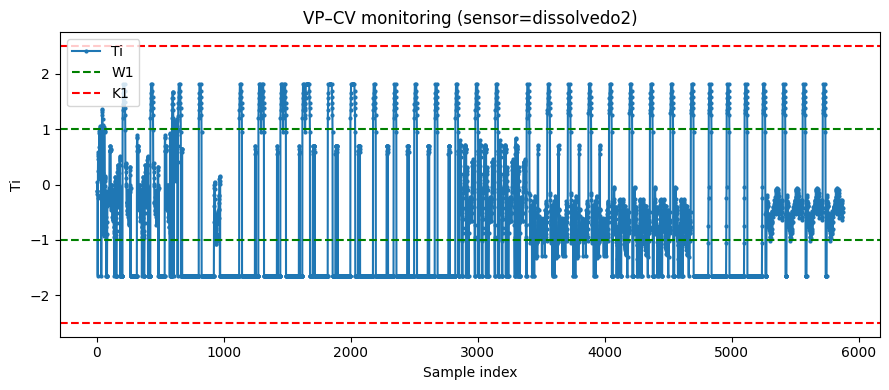

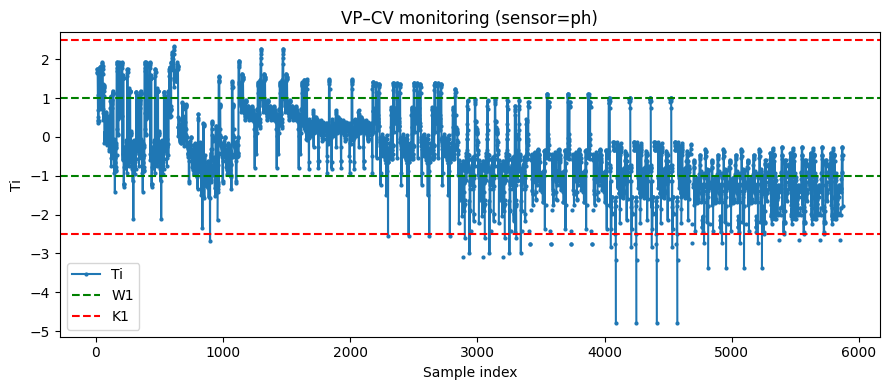

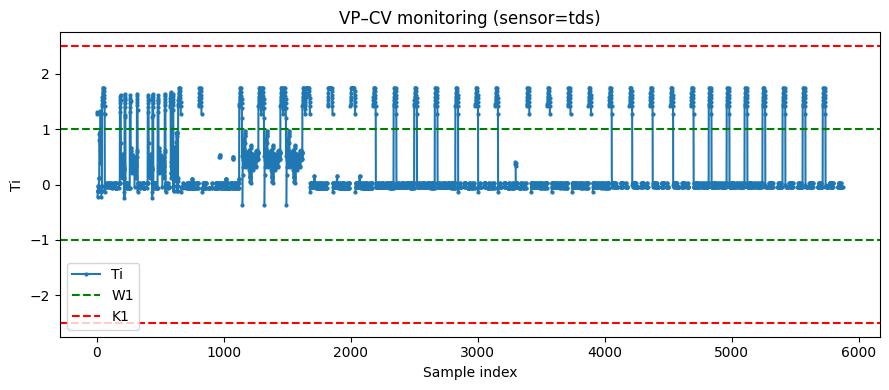

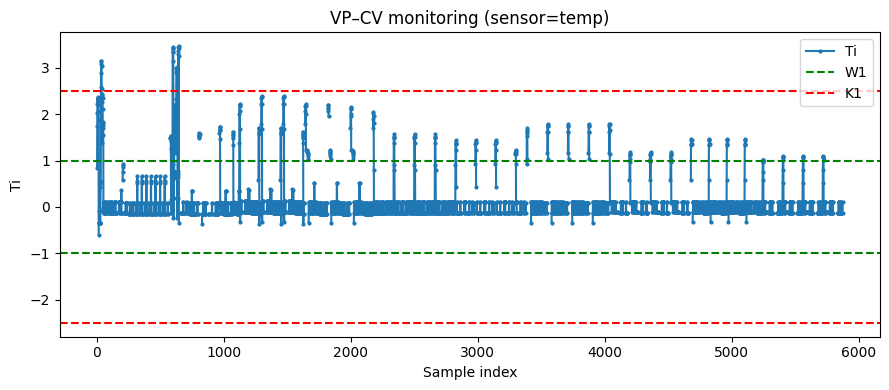

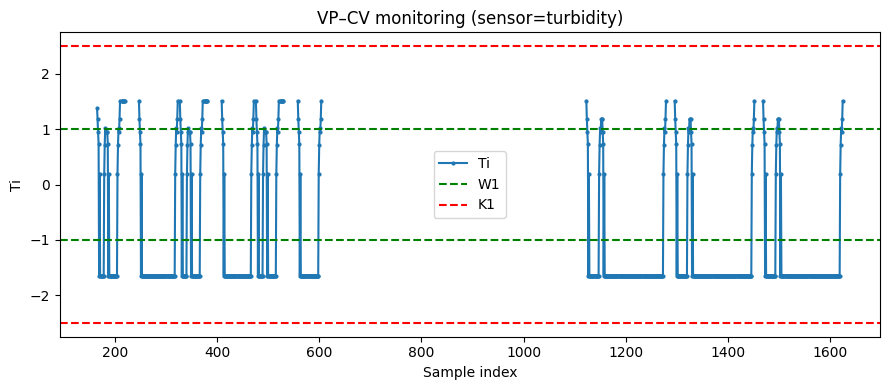

/tmp/ipython-input-3803155346.py:104: RuntimeWarning: invalid value encountered in log
  a = -b * np.log((x05 - xr) / (1 - np.exp(z_r / b)))


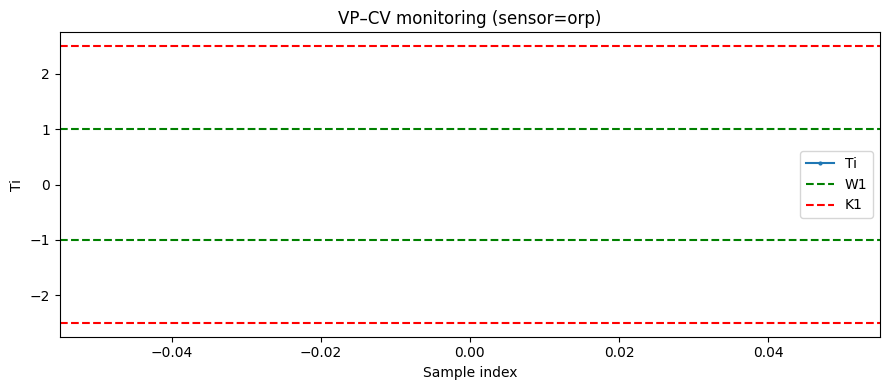

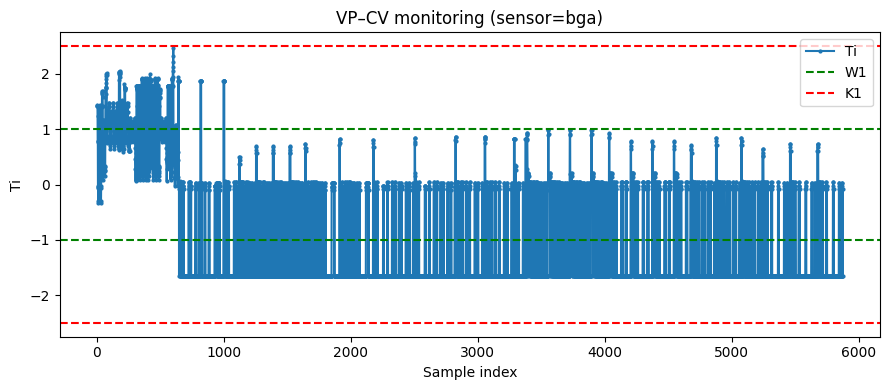

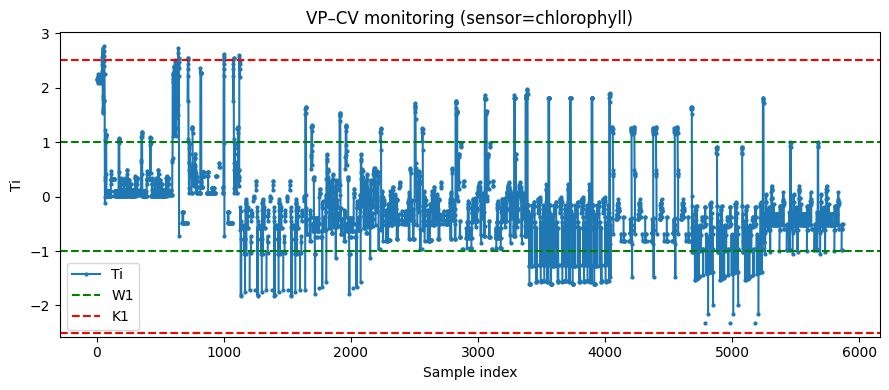


=== Sensor Stability Summary (Robust CV + ASSD + VP–CV) ===
        sensor     mean   median  robust_cv_%  assd_stable_index  \
0  dissolvedo2    95.06   109.35        19.06                  5   
1           ph     5.12     4.83         7.21                  5   
2          tds  1690.33  2106.38         1.08                  6   
3         temp    28.03    27.88         0.45                  5   
4    turbidity     0.61     0.00          NaN                  5   
5          orp -3601.36 -3770.00        35.23                  7   
6          bga  1413.40    29.00         1.03                  8   
7  chlorophyll   189.73   207.30        13.89                  5   

   vp_cv_out_of_control_ratio     vp_cv_classification  
0                      0.0000  stable after adjustment  
1                      0.0352     bounded fluctuations  
2                      0.0000  stable after adjustment  
3                      0.0264     bounded fluctuations  
4                      0.0000  stable aft

In [ ]:
"""
Aquatic Explorer – Sensor Stability Analysis
- Robust CV (R-CV)
- ASSD (Adaptive Sensor Stabilization Detection)
- Simplified VP-CV classification

Save as: sensor_stability_analysis.py
Run:    python sensor_stability_analysis.py
"""

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt


# ---------- Helper: Robust CV (median / MAD) ----------

def robust_cv(series):
    """Robust Coefficient of Variation: MAD / median (in %)"""
    x = series.dropna().values.astype(float)
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    if med == 0:
        return np.nan
    mad = np.median(np.abs(x - med))
    return float(mad / np.abs(med) * 100.0)


# ---------- Helper: ASSD (stabilization index only) ----------

def assd_detect_stabilization(values, window=3, threshold_var=0.02, consecutive=3):
    """
    Adaptive Sensor Stabilization Detection.
    - Standardizes the series.
    - Computes rolling variance on z-scores.
    - Returns index where variance stays below threshold for `consecutive` steps.
    """
    x = np.asarray(values, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < window + consecutive:
        return None

    # Standardize
    std = x.std(ddof=1)
    if std == 0:
        return None
    z = (x - x.mean()) / std

    stable_idx = None
    stable_count = 0

    for i in range(window, len(z)):
        v = np.var(z[i-window:i])
        if v < threshold_var:
            stable_count += 1
            if stable_count >= consecutive and stable_idx is None:
                stable_idx = i
        else:
            stable_count = 0

    return stable_idx  # index in the cleaned (dropna) series


# ---------- Helpers for VP–CV ----------

def sliding_sample_cv(series, window):
    x = series.values.astype(float)
    gammas = []
    idx = []
    for i in range(len(x) - window + 1):
        block = x[i:i+window]
        block = block[~np.isnan(block)]
        if len(block) < 2:
            gammas.append(np.nan)
        else:
            mu = block.mean()
            sd = block.std(ddof=1)
            gammas.append(sd / mu if mu != 0 else np.nan)
        idx.append(i + window - 1)
    return np.array(gammas), np.array(idx)


def fit_3param_lognormal_from_quantiles(gamma_samples, r=0.05):
    """Fit 3-parameter lognormal using empirical quantiles (simplified)."""
    gamma_samples = gamma_samples[~np.isnan(gamma_samples)]
    if len(gamma_samples) < 20:
        return None

    xr  = np.quantile(gamma_samples, r)
    x05 = np.quantile(gamma_samples, 0.5)
    x1r = np.quantile(gamma_samples, 1-r)
    if not (xr < x05 < x1r):
        return None

    z_r = norm.ppf(r)
    num = x05 - xr
    den = x1r - x05
    if num <= 0 or den <= 0:
        return None

    b = z_r / np.log(num/den)
    a = -b * np.log((x05 - xr) / (1 - np.exp(z_r / b)))
    c = x05 - np.exp(-a / b)
    return float(a), float(b), float(c)


def gamma_to_T(gamma, a, b, c):
    if np.isnan(gamma) or gamma <= c:
        return np.nan
    return a + b * np.log(gamma - c)


def vp_cv_monitor_simple(series, sensor_name,
                         n1=5, n2=7,
                         W1=1.0, K1=2.5,
                         W2=0.8, K2=2.0,
                         make_plot=False):
    """
    Simplified VP–CV monitor.
    Returns: out_of_control_ratio (0–1), classification string
    """
    s = series.dropna().reset_index(drop=True)
    if len(s) < max(n1, n2) * 6:
        return np.nan, "insufficient data"

    gam_hist, _ = sliding_sample_cv(s, window=max(n1, n2) * 3)
    fit = fit_3param_lognormal_from_quantiles(gam_hist)
    if fit is None:
        return np.nan, "fit_failed"

    a, b, c = fit

    # compute Ti for two sample sizes
    gam1, idx1 = sliding_sample_cv(s, n1)
    gam2, idx2 = sliding_sample_cv(s, n2)
    T1 = np.array([gamma_to_T(g, a, b, c) for g in gam1])
    T2 = np.array([gamma_to_T(g, a, b, c) for g in gam2])

    state = 1
    flags = []
    max_t = max(idx1[-1], idx2[-1])

    for t in range(max_t + 1):
        if state == 1:
            loc = np.where(idx1 == t)[0]
            Ti = T1[loc[0]] if len(loc) else np.nan
            W, K = W1, K1
        else:
            loc = np.where(idx2 == t)[0]
            Ti = T2[loc[0]] if len(loc) else np.nan
            W, K = W2, K2

        if np.isnan(Ti):
            action = "wait"
        else:
            if abs(Ti) <= W:
                action = "central_keep"
                state = 1
            elif W < abs(Ti) <= K:
                action = "warning_switch"
                state = 2
            else:
                action = "out_of_control"
                state = 2
        flags.append((t, Ti, action))

    flags_df = pd.DataFrame(flags, columns=["time_idx", "Ti", "action"])
    total_valid = (flags_df["action"] != "wait").sum()
    num_ooc = (flags_df["action"] == "out_of_control").sum()
    ratio = num_ooc / total_valid if total_valid > 0 else np.nan

    # classify
    if np.isnan(ratio):
        classification = "insufficient data"
    elif ratio < 0.01:
        classification = "stable after adjustment"
    elif ratio < 0.05:
        classification = "bounded fluctuations"
    else:
        classification = "high variability"

    if make_plot:
        plt.figure(figsize=(9, 4))
        plt.plot(flags_df["time_idx"], flags_df["Ti"], "o-", ms=2, label="Ti")
        plt.axhline(W1, color="green", linestyle="--", label="W1")
        plt.axhline(-W1, color="green", linestyle="--")
        plt.axhline(K1, color="red", linestyle="--", label="K1")
        plt.axhline(-K1, color="red", linestyle="--")
        plt.title(f"VP–CV monitoring (sensor={sensor_name})")
        plt.xlabel("Sample index")
        plt.ylabel("Ti")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return float(ratio), classification


# ---------- MAIN SCRIPT ----------

def main():
    # === EDIT THIS PATH FOR YOUR FILE ===
    # 3. Load dataset  (EDIT THIS PATH)
    file_path = "/content/drive/MyDrive/Sensor_data_premonsoon.csv"


    df = pd.read_csv(file_path)
    df.columns = [c.strip().lower() for c in df.columns]

    sensors = [
        "dissolvedo2", "ph", "tds", "temp",
        "turbidity", "orp", "bga", "chlorophyll"
    ]
    sensors = [s for s in sensors if s in df.columns]

    rows = []

    for sensor in sensors:
        series = df[sensor].astype(float)
        rcv = robust_cv(series)
        stable_idx = assd_detect_stabilization(series.values)
        ratio, cls = vp_cv_monitor_simple(series, sensor_name=sensor, make_plot=True)

        rows.append({
            "sensor": sensor,
            "mean": round(series.mean(), 2),
            "median": round(series.median(), 2),
            "robust_cv_%": round(rcv, 2) if rcv == rcv else np.nan,
            "assd_stable_index": stable_idx,
            "vp_cv_out_of_control_ratio": round(ratio, 4) if ratio == ratio else np.nan,
            "vp_cv_classification": cls
        })

    summary = pd.DataFrame(rows)
    print("\n=== Sensor Stability Summary (Robust CV + ASSD + VP–CV) ===")
    print(summary)

    # optional: save to CSV for your paper
    summary.to_csv("sensor_stability_summary.csv", index=False)
    print("\nSaved summary to sensor_stability_summary.csv")

if __name__ == "__main__":
    main()


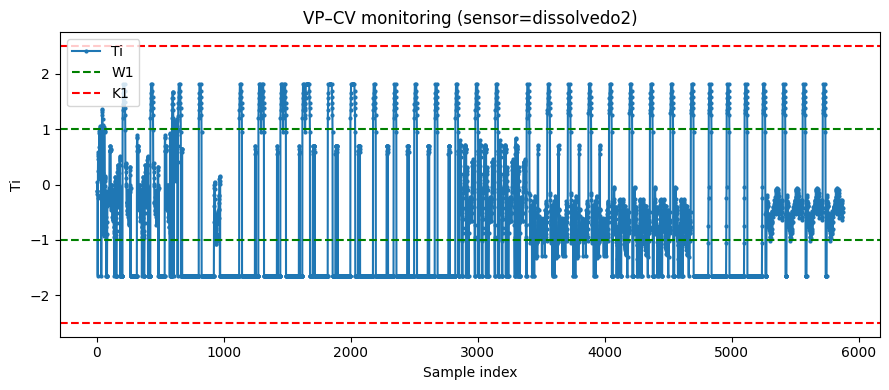

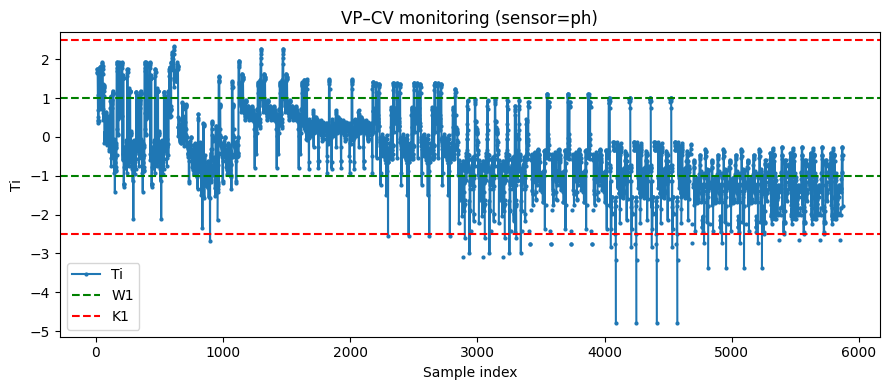

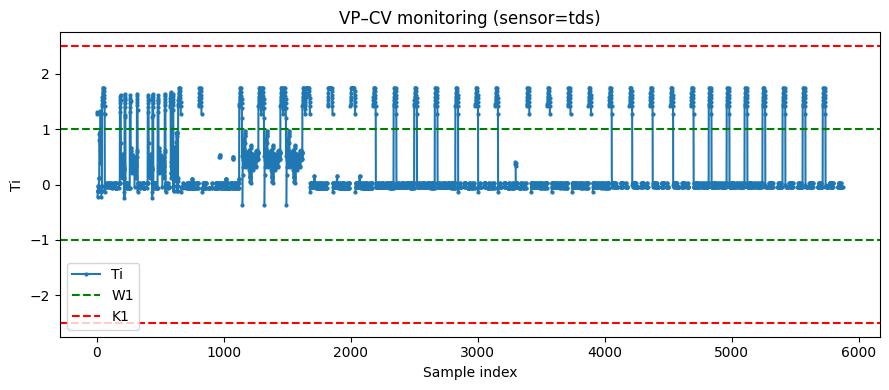

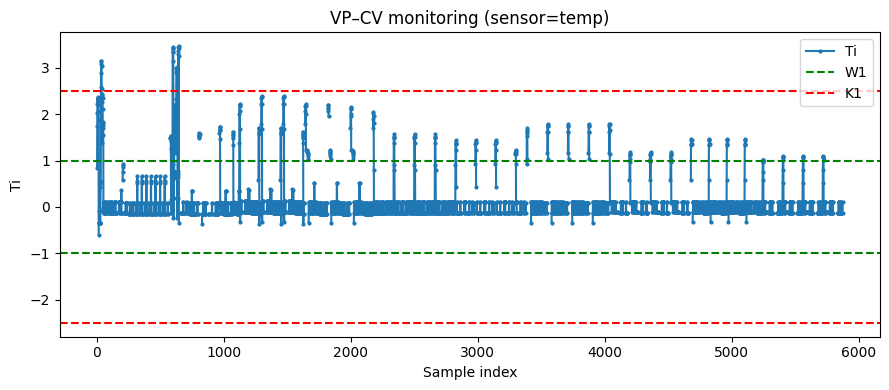

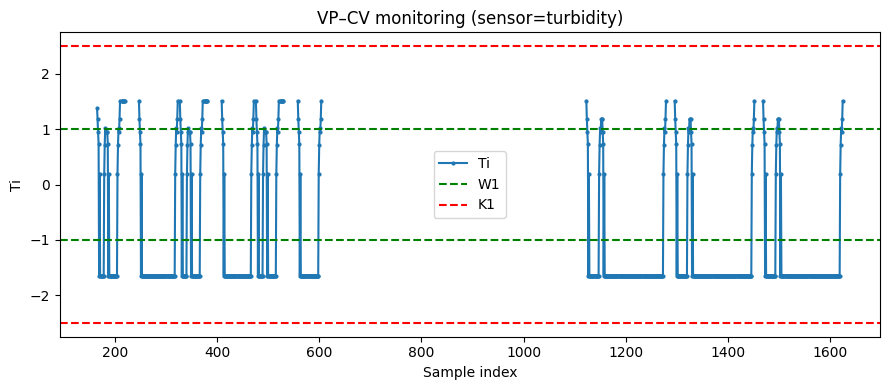

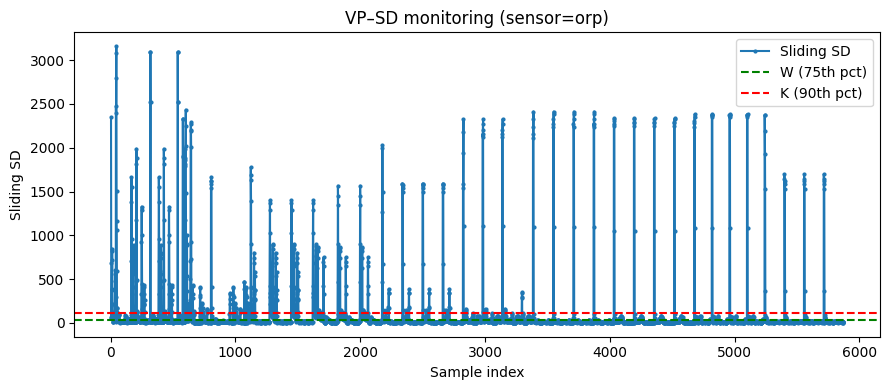

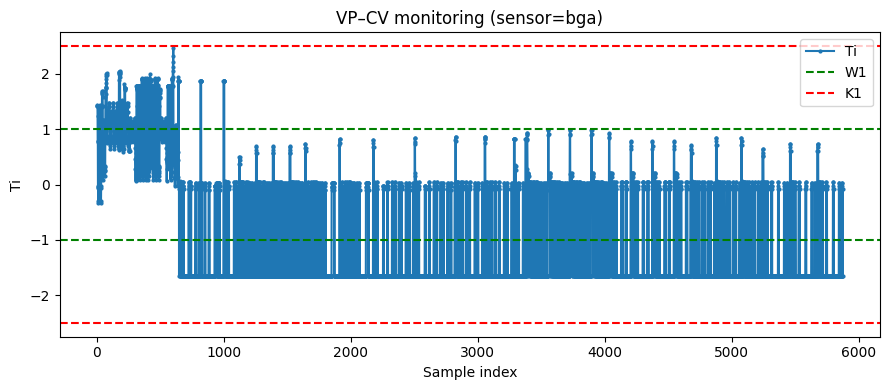

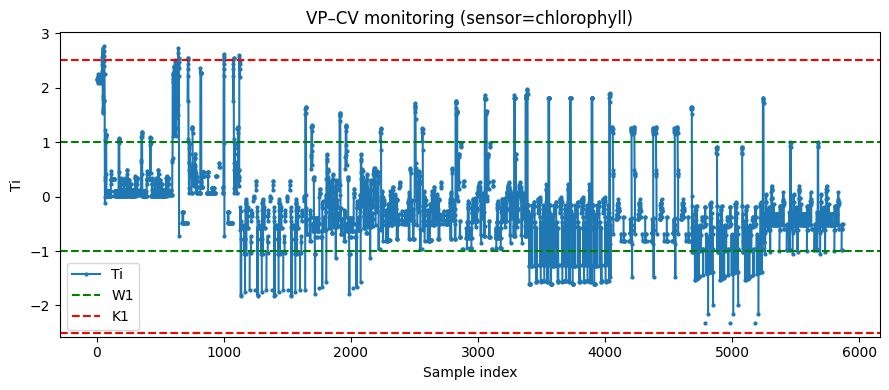


=== Sensor Stability Summary (Robust CV + ASSD + VP–CV/VP–SD) ===
        sensor     mean   median  robust_cv_%  assd_stable_index  \
0  dissolvedo2    95.06   109.35        19.06                  5   
1           ph     5.12     4.83         7.21                  5   
2          tds  1690.33  2106.38         1.08                  6   
3         temp    28.03    27.88         0.45                  5   
4    turbidity     0.61     0.00          NaN                  5   
5          orp -3601.36 -3770.00        35.23                  7   
6          bga  1413.40    29.00         1.03                  8   
7  chlorophyll   189.73   207.30        13.89                  5   

  stability_metric  stability_out_of_control_ratio stability_classification  
0            VP-CV                          0.0000  stable after adjustment  
1            VP-CV                          0.0352     bounded fluctuations  
2            VP-CV                          0.0000  stable after adjustment  
3       

In [ ]:
"""
Aquatic Explorer – Sensor Stability Analysis (with ORP via VP–SD)

- For all sensors:
    - Robust CV (median/MAD)
    - ASSD (Adaptive Sensor Stabilization Detection)

- For non-ORP sensors:
    - VP–CV (Variable-Parameter CV control chart)

- For ORP only:
    - VP–SD (sliding standard-deviation control chart, sign-independent)

Save as: sensor_stability_with_orp.py
"""

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt


# ---------- 1. Robust CV (Median / MAD) ----------

def robust_cv(series, use_abs_median=False):
    """Robust Coefficient of Variation in %.
       If use_abs_median=True (for ORP), divides by |median|."""
    x = series.dropna().values.astype(float)
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    if med == 0:
        return np.nan
    if use_abs_median:
        med = abs(med)
    mad = np.median(np.abs(x - np.median(x)))
    return float(mad / med * 100.0)


# ---------- 2. ASSD (Adaptive Sensor Stabilization Detection) ----------

def assd_detect_stabilization(values, window=3, threshold_var=0.02, consecutive=3):
    """
    Adaptive Sensor Stabilization Detection.
    - Standardizes the series.
    - Computes rolling variance on z-scores.
    - Returns index where variance stays below threshold for `consecutive` steps.
    """
    x = np.asarray(values, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < window + consecutive:
        return None

    std = x.std(ddof=1)
    if std == 0:
        return None
    z = (x - x.mean()) / std

    stable_idx = None
    stable_count = 0
    for i in range(window, len(z)):
        v = np.var(z[i-window:i])
        if v < threshold_var:
            stable_count += 1
            if stable_count >= consecutive and stable_idx is None:
                stable_idx = i
        else:
            stable_count = 0
    return stable_idx


# ---------- 3. VP–CV helpers (for non-ORP sensors) ----------

def sliding_sample_cv(series, window):
    x = series.values.astype(float)
    gammas, idx = [], []
    for i in range(len(x) - window + 1):
        block = x[i:i+window]
        block = block[~np.isnan(block)]
        if len(block) < 2:
            gammas.append(np.nan)
        else:
            mu = block.mean()
            sd = block.std(ddof=1)
            gammas.append(sd / mu if mu != 0 else np.nan)
        idx.append(i + window - 1)
    return np.array(gammas), np.array(idx)

def fit_3param_lognormal_from_quantiles(gamma_samples, r=0.05):
    gamma_samples = gamma_samples[~np.isnan(gamma_samples)]
    if len(gamma_samples) < 20:
        return None
    xr  = np.quantile(gamma_samples, r)
    x05 = np.quantile(gamma_samples, 0.5)
    x1r = np.quantile(gamma_samples, 1-r)
    if not (xr < x05 < x1r):
        return None

    z_r = norm.ppf(r)
    num = x05 - xr
    den = x1r - x05
    if num <= 0 or den <= 0:
        return None

    b = z_r / np.log(num/den)
    a = -b * np.log((x05 - xr) / (1 - np.exp(z_r / b)))
    c = x05 - np.exp(-a / b)
    return float(a), float(b), float(c)

def gamma_to_T(gamma, a, b, c):
    if np.isnan(gamma) or gamma <= c:
        return np.nan
    return a + b * np.log(gamma - c)

def vp_cv_monitor_simple(series, sensor_name,
                         n1=5, n2=7,
                         W1=1.0, K1=2.5,
                         W2=0.8, K2=2.0,
                         make_plot=False):
    """
    Simplified VP–CV monitor for positive-domain sensors.
    Returns: out_of_control_ratio (0–1), classification string.
    """
    s = series.dropna().reset_index(drop=True)
    if len(s) < max(n1, n2) * 6:
        return np.nan, "insufficient data"

    gam_hist, _ = sliding_sample_cv(s, window=max(n1, n2) * 3)
    fit = fit_3param_lognormal_from_quantiles(gam_hist)
    if fit is None:
        return np.nan, "fit_failed"

    a, b, c = fit
    gam1, idx1 = sliding_sample_cv(s, n1)
    gam2, idx2 = sliding_sample_cv(s, n2)
    T1 = np.array([gamma_to_T(g, a, b, c) for g in gam1])
    T2 = np.array([gamma_to_T(g, a, b, c) for g in gam2])

    state = 1
    flags = []
    max_t = max(idx1[-1], idx2[-1])
    for t in range(max_t + 1):
        if state == 1:
            loc = np.where(idx1 == t)[0]
            Ti = T1[loc[0]] if len(loc) else np.nan
            W, K = W1, K1
        else:
            loc = np.where(idx2 == t)[0]
            Ti = T2[loc[0]] if len(loc) else np.nan
            W, K = W2, K2

        if np.isnan(Ti):
            action = "wait"
        else:
            if abs(Ti) <= W:
                action = "central_keep"
                state = 1
            elif W < abs(Ti) <= K:
                action = "warning_switch"
                state = 2
            else:
                action = "out_of_control"
                state = 2
        flags.append((t, Ti, action))

    flags_df = pd.DataFrame(flags, columns=["time_idx", "Ti", "action"])
    total_valid = (flags_df["action"] != "wait").sum()
    num_ooc = (flags_df["action"] == "out_of_control").sum()
    ratio = num_ooc / total_valid if total_valid > 0 else np.nan

    if np.isnan(ratio):
        classification = "insufficient data"
    elif ratio < 0.01:
        classification = "stable after adjustment"
    elif ratio < 0.05:
        classification = "bounded fluctuations"
    else:
        classification = "high variability"

    if make_plot:
        plt.figure(figsize=(9, 4))
        plt.plot(flags_df["time_idx"], flags_df["Ti"], "o-", ms=2, label="Ti")
        plt.axhline(W1, color="green", linestyle="--", label="W1")
        plt.axhline(-W1, color="green", linestyle="--")
        plt.axhline(K1, color="red", linestyle="--", label="K1")
        plt.axhline(-K1, color="red", linestyle="--")
        plt.title(f"VP–CV monitoring (sensor={sensor_name})")
        plt.xlabel("Sample index")
        plt.ylabel("Ti")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return float(ratio), classification


# ---------- 4. VP–SD for ORP (sign-independent) ----------

def vp_sd_monitor(series, sensor_name,
                  window=5,
                  make_plot=False):
    """
    VP–SD monitor for ORP (uses sliding standard deviation instead of CV).
    Thresholds W, K are empirical (75th and 90th percentile of SD).
    Returns: out_of_control_ratio, classification string.
    """
    s = series.dropna().values.astype(float)
    if len(s) < window * 6:
        return np.nan, "insufficient data"

    sds = []
    idxs = []
    for i in range(len(s) - window + 1):
        block = s[i:i+window]
        sds.append(block.std(ddof=1))
        idxs.append(i + window - 1)

    sds = np.array(sds)
    idxs = np.array(idxs)

    # Empirical thresholds
    W = np.quantile(sds, 0.75)
    K = np.quantile(sds, 0.90)

    out_of_control = (sds > K).sum()
    total = len(sds)
    ratio = out_of_control / total if total > 0 else np.nan

    if np.isnan(ratio):
        classification = "insufficient data"
    elif ratio < 0.01:
        classification = "stable after adjustment"
    elif ratio < 0.05:
        classification = "bounded fluctuations"
    else:
        classification = "high variability"

    if make_plot:
        plt.figure(figsize=(9, 4))
        plt.plot(idxs, sds, "o-", ms=2, label="Sliding SD")
        plt.axhline(W, color="green", linestyle="--", label="W (75th pct)")
        plt.axhline(K, color="red", linestyle="--", label="K (90th pct)")
        plt.title(f"VP–SD monitoring (sensor={sensor_name})")
        plt.xlabel("Sample index")
        plt.ylabel("Sliding SD")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return float(ratio), classification


# ---------- 5. MAIN SCRIPT ----------

def main():
    # === EDIT THIS PATH ===
    csv_path = "/content/drive/MyDrive/Sensor_data_premonsoon.csv"

    df = pd.read_csv(csv_path)
    df.columns = [c.strip().lower() for c in df.columns]

    sensors = ["dissolvedo2", "ph", "tds", "temp",
               "turbidity", "orp", "bga", "chlorophyll"]
    sensors = [s for s in sensors if s in df.columns]

    rows = []

    for sensor in sensors:
        series = df[sensor].astype(float)

        # Robust CV: use abs(median) for ORP, normal for others
        use_abs = (sensor == "orp")
        rcv = robust_cv(series, use_abs_median=use_abs)

        # ASSD
        stable_idx = assd_detect_stabilization(series.values)

        # VP–CV for non-ORP, VP–SD for ORP
        if sensor == "orp":
            ratio, cls = vp_sd_monitor(series, sensor_name=sensor, make_plot=True)
            metric_type = "VP-SD"
        else:
            ratio, cls = vp_cv_monitor_simple(series, sensor_name=sensor, make_plot=True)
            metric_type = "VP-CV"

        rows.append({
            "sensor": sensor,
            "mean": round(series.mean(), 2),
            "median": round(series.median(), 2),
            "robust_cv_%": round(rcv, 2) if rcv == rcv else np.nan,
            "assd_stable_index": stable_idx,
            "stability_metric": metric_type,
            "stability_out_of_control_ratio": round(ratio, 4) if ratio == ratio else np.nan,
            "stability_classification": cls
        })

    summary = pd.DataFrame(rows)
    print("\n=== Sensor Stability Summary (Robust CV + ASSD + VP–CV/VP–SD) ===")
    print(summary)

    summary.to_csv("sensor_stability_summary_with_orp.csv", index=False)
    print("\nSaved summary to sensor_stability_summary_with_orp.csv")

if __name__ == "__main__":
    main()


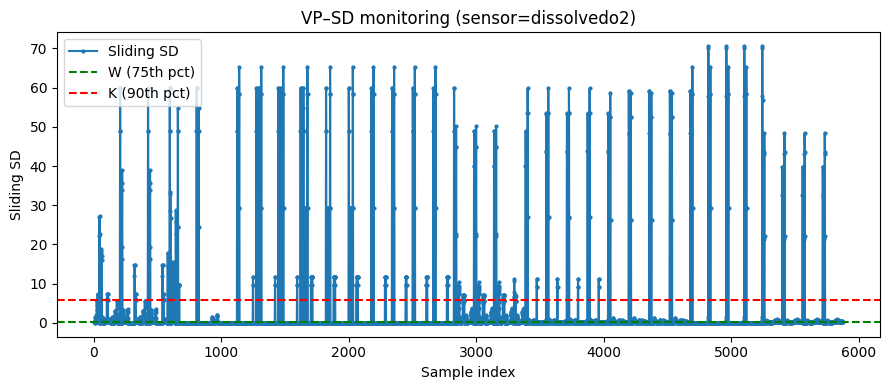

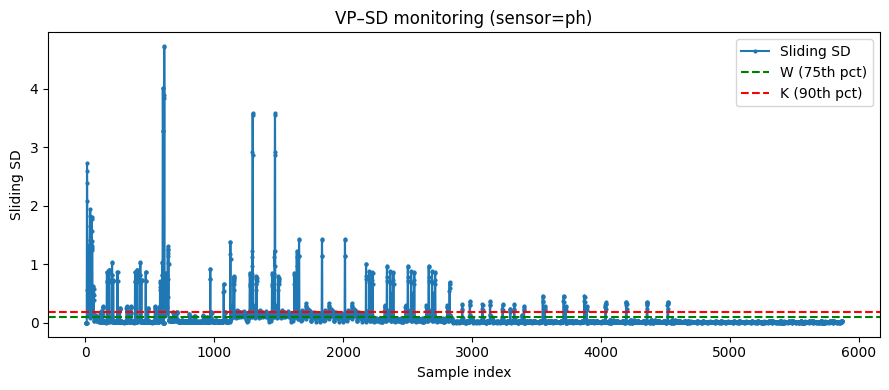

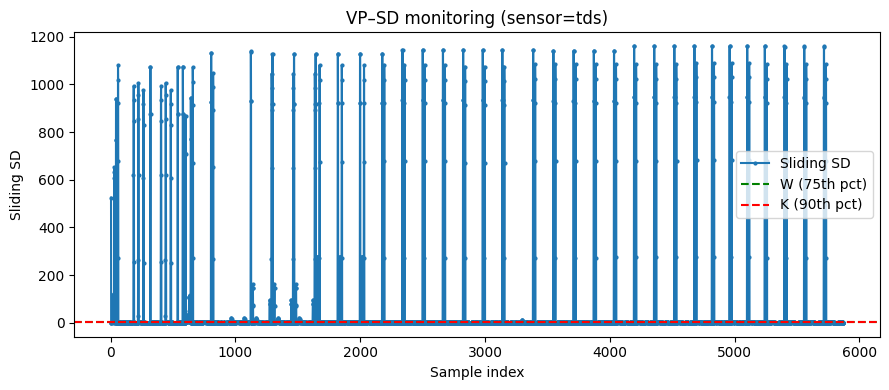

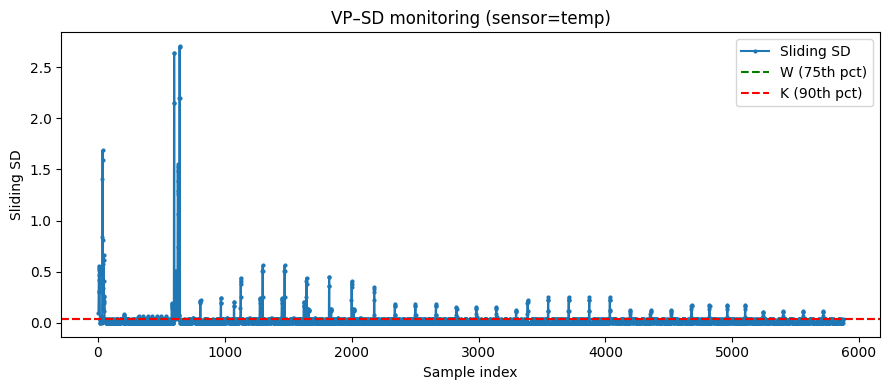

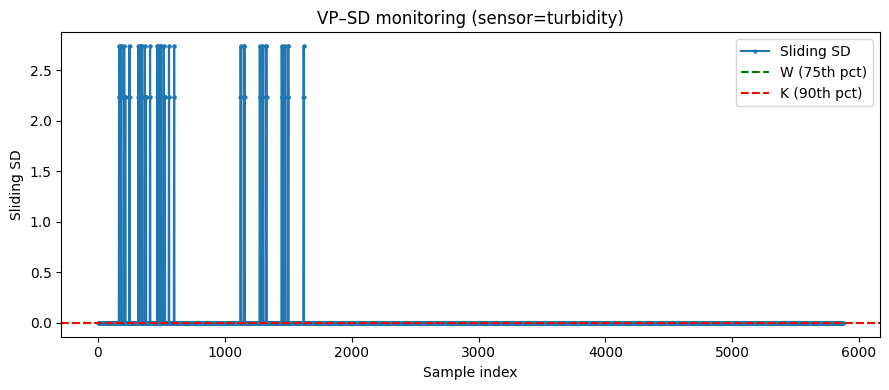

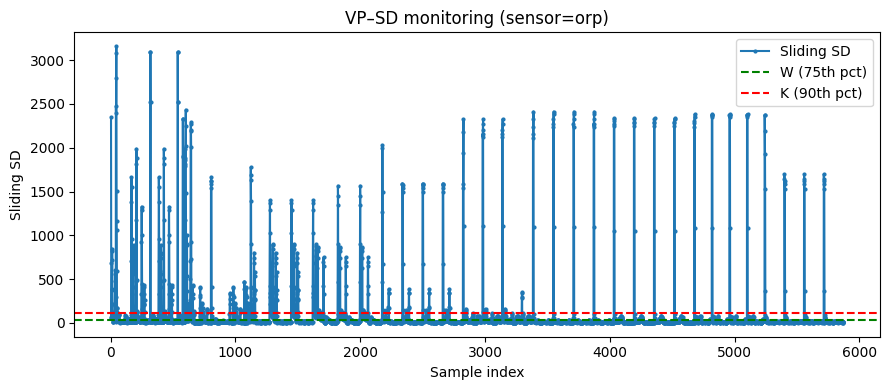

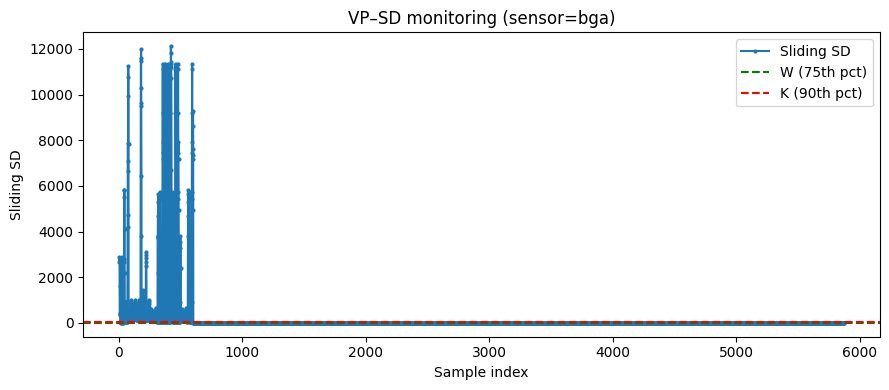

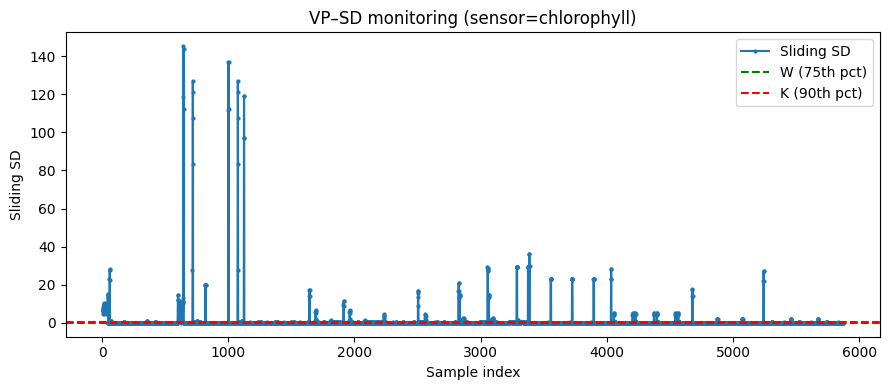


=== Sensor Stability Summary (Robust CV + ASSD + VP–SD) ===
        sensor     mean   median  robust_cv_%  assd_stable_index  \
0  dissolvedo2    95.06   109.35        19.06                  5   
1           ph     5.12     4.83         7.21                  5   
2          tds  1690.33  2106.38         1.08                  6   
3         temp    28.03    27.88         0.45                  5   
4    turbidity     0.61     0.00          NaN                  5   
5          orp -3601.36 -3770.00        35.23                  7   
6          bga  1413.40    29.00         1.03                  8   
7  chlorophyll   189.73   207.30        13.89                  5   

   stability_out_of_control_ratio stability_classification  
0                          0.0998         high variability  
1                          0.0998         high variability  
2                          0.0997         high variability  
3                          0.0547         high variability  
4                    

In [ ]:
"""
Aquatic Explorer – Sensor Stability Analysis (VP–SD for all sensors)

- Robust CV (median / MAD)
- ASSD (Adaptive Sensor Stabilization Detection)
- VP–SD (sliding standard deviation chart) for every sensor
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Robust CV (Median / MAD) ----------

def robust_cv(series, use_abs_median=False):
    x = series.dropna().values.astype(float)
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    if med == 0:
        return np.nan
    if use_abs_median:
        med = abs(med)
    mad = np.median(np.abs(x - np.median(x)))
    return float(mad / med * 100.0)


# ---------- ASSD (stabilization index) ----------

def assd_detect_stabilization(values, window=3, threshold_var=0.02, consecutive=3):
    x = np.asarray(values, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < window + consecutive:
        return None

    std = x.std(ddof=1)
    if std == 0:
        return None
    z = (x - x.mean()) / std

    stable_idx = None
    stable_count = 0
    for i in range(window, len(z)):
        v = np.var(z[i-window:i])
        if v < threshold_var:
            stable_count += 1
            if stable_count >= consecutive and stable_idx is None:
                stable_idx = i
        else:
            stable_count = 0
    return stable_idx


# ---------- VP–SD for all sensors ----------

def vp_sd_monitor(series, sensor_name,
                  window=5,
                  make_plot=False):
    """
    Variable-parameter SD chart for stability:
    - Sliding SD over 'window' points
    - W = 75th percentile, K = 90th percentile of SD
    - Returns (out_of_control_ratio, classification)
    """
    s = series.dropna().values.astype(float)
    if len(s) < window * 6:
        return np.nan, "insufficient data"

    sds = []
    idxs = []
    for i in range(len(s) - window + 1):
        block = s[i:i+window]
        sds.append(block.std(ddof=1))
        idxs.append(i + window - 1)

    sds = np.array(sds)
    idxs = np.array(idxs)

    W = np.quantile(sds, 0.75)
    K = np.quantile(sds, 0.90)

    out_of_control = (sds > K).sum()
    total = len(sds)
    ratio = out_of_control / total if total > 0 else np.nan

    if np.isnan(ratio):
        classification = "insufficient data"
    elif ratio < 0.01:
        classification = "stable after adjustment"
    elif ratio < 0.05:
        classification = "bounded fluctuations"
    else:
        classification = "high variability"

    if make_plot:
        plt.figure(figsize=(9, 4))
        plt.plot(idxs, sds, "o-", ms=2, label="Sliding SD")
        plt.axhline(W, color="green", linestyle="--", label="W (75th pct)")
        plt.axhline(K, color="red", linestyle="--", label="K (90th pct)")
        plt.title(f"VP–SD monitoring (sensor={sensor_name})")
        plt.xlabel("Sample index")
        plt.ylabel("Sliding SD")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return float(ratio), classification


# ---------- MAIN SCRIPT ----------

def main():
    # === EDIT THIS PATH ===
    csv_path = "/content/drive/MyDrive/Sensor_data_premonsoon.csv"

    df = pd.read_csv(csv_path)
    df.columns = [c.strip().lower() for c in df.columns]

    sensors = ["dissolvedo2", "ph", "tds", "temp",
               "turbidity", "orp", "bga", "chlorophyll"]
    sensors = [s for s in sensors if s in df.columns]

    rows = []

    for sensor in sensors:
        series = df[sensor].astype(float)

        # Robust CV: use absolute median for ORP (optional)
        use_abs = (sensor == "orp")
        rcv = robust_cv(series, use_abs_median=use_abs)

        stable_idx = assd_detect_stabilization(series.values)

        ratio, cls = vp_sd_monitor(series, sensor_name=sensor, make_plot=True)

        rows.append({
            "sensor": sensor,
            "mean": round(series.mean(), 2),
            "median": round(series.median(), 2),
            "robust_cv_%": round(rcv, 2) if rcv == rcv else np.nan,
            "assd_stable_index": stable_idx,
            "stability_out_of_control_ratio": round(ratio, 4) if ratio == ratio else np.nan,
            "stability_classification": cls
        })

    summary = pd.DataFrame(rows)
    print("\n=== Sensor Stability Summary (Robust CV + ASSD + VP–SD) ===")
    print(summary)

    summary.to_csv("sensor_stability_summary_vpsd_all.csv", index=False)
    print("\nSaved summary to sensor_stability_summary_vpsd_all.csv")

if __name__ == "__main__":
    main()


In [ ]:
"""
Aquatic Explorer – Simple Sensor Stabilization Check

For each sensor:
- Mean, Median, Std
- Robust CV (median/MAD) – informational
- ASSD stabilization index
- Status: 'stabilized' if ASSD finds a stable point
"""

import numpy as np
import pandas as pd

# ---------- Robust CV (Median / MAD) ----------
def robust_cv(series, use_abs_median=False):
    x = series.dropna().values.astype(float)
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    if med == 0:
        return np.nan
    if use_abs_median:
        med = abs(med)
    mad = np.median(np.abs(x - np.median(x)))
    return float(mad / med * 100.0)

# ---------- ASSD (Adaptive Sensor Stabilization Detection) ----------
def assd_detect_stabilization(values, window=3, threshold_var=0.02, consecutive=3):
    """
    Sensor is 'stabilized' when rolling variance of standardized readings
    stays below threshold_var for 'consecutive' windows.
    Returns index of stabilization (in the cleaned series) or None.
    """
    x = np.asarray(values, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < window + consecutive:
        return None

    std = x.std(ddof=1)
    if std == 0:
        return None
    z = (x - x.mean()) / std

    stable_idx = None
    stable_count = 0
    for i in range(window, len(z)):
        v = np.var(z[i-window:i])
        if v < threshold_var:
            stable_count += 1
            if stable_count >= consecutive and stable_idx is None:
                stable_idx = i
        else:
            stable_count = 0
    return stable_idx

# ---------- MAIN SCRIPT ----------
def main():
    # === EDIT THIS PATH ===
    csv_path = "/content/drive/MyDrive/Sensor_data_premonsoon.csv"

    df = pd.read_csv(csv_path)
    df.columns = [c.strip().lower() for c in df.columns]

    sensors = ["dissolvedo2", "ph", "tds", "temp",
               "turbidity", "orp", "bga", "chlorophyll"]
    sensors = [s for s in sensors if s in df.columns]

    rows = []

    for sensor in sensors:
        series = df[sensor].astype(float)

        # For ORP you can optionally use abs(median) in R-CV
        use_abs = (sensor == "orp")
        rcv = robust_cv(series, use_abs_median=use_abs)

        stable_idx = assd_detect_stabilization(series.values)

        status = "stabilized" if stable_idx is not None else "not_stabilized"

        rows.append({
            "sensor": sensor,
            "mean": round(series.mean(), 2),
            "median": round(series.median(), 2),
            "std": round(series.std(ddof=1), 2),
            "robust_cv_%": round(rcv, 2) if rcv == rcv else np.nan,
            "assd_stable_index": stable_idx,
            "status": status
        })

    summary = pd.DataFrame(rows)
    print("\n=== Sensor Stabilization Summary (ASSD) ===")
    print(summary)

    summary.to_csv("sensor_stabilization_assd_only.csv", index=False)
    print("\nSaved summary to sensor_stabilization_assd_only.csv")

if __name__ == "__main__":
    main()



=== Sensor Stabilization Summary (ASSD) ===
        sensor     mean   median      std  robust_cv_%  assd_stable_index  \
0  dissolvedo2    95.06   109.35    38.17        19.06                  5   
1           ph     5.12     4.83     1.51         7.21                  5   
2          tds  1690.33  2106.38   808.95         1.08                  6   
3         temp    28.03    27.88     0.65         0.45                  5   
4    turbidity     0.61     0.00     1.64          NaN                  5   
5          orp -3601.36 -3770.00  1891.22        35.23                  7   
6          bga  1413.40    29.00  4471.96         1.03                  8   
7  chlorophyll   189.73   207.30    71.48        13.89                  5   

       status  
0  stabilized  
1  stabilized  
2  stabilized  
3  stabilized  
4  stabilized  
5  stabilized  
6  stabilized  
7  stabilized  

Saved summary to sensor_stabilization_assd_only.csv


**Per-Site Stability Analysis**

In [ ]:
import numpy as np
import pandas as pd

# ---------- A. Robust CV ----------
def robust_cv(series, use_abs=False):
    x = series.dropna().values.astype(float)
    if len(x) == 0:
        return np.nan
    median = np.median(x)
    if median == 0:
        return np.nan
    if use_abs:
        median = abs(median)
    mad = np.median(np.abs(x - np.median(x)))
    return float(mad / median * 100)


# ---------- B. ASSD Stabilization ----------
def assd(values, window=5, threshold=0.02, consecutive=3):
    x = np.asarray(values, dtype=float)
    if len(x) < window + consecutive:
        return None
    z = (x - np.mean(x)) / np.std(x)
    stable_count = 0
    for i in range(window, len(z)):
        v = np.var(z[i-window:i])
        if v < threshold:
            stable_count += 1
            if stable_count >= consecutive:
                return i
        else:
            stable_count = 0
    return None


# ---------- C. Moving SD ----------
def moving_sd(values, window=5):
    x = np.asarray(values, dtype=float)
    sds = []
    for i in range(len(x) - window + 1):
        sds.append(np.std(x[i:i+window], ddof=1))
    return np.mean(sds) if sds else np.nan


# ---------- D. Stability Classification ----------
def classify(stable_idx, rcv):
    if stable_idx is None:
        return "High variability"
    if rcv is np.nan:
        return "Stable (zero variation)"
    if rcv < 10:
        return "Stable after adjustment"
    elif rcv < 30:
        return "Bounded fluctuations"
    else:
        return "High variability"


# ----------- MAIN (Per-site Processing) -----------
def main():
    df = pd.read_csv("/content/drive/MyDrive/Sensor_data_premonsoon.csv")
    df.columns = [c.lower().strip() for c in df.columns]

    sensors = ["dissolvedo2", "ph", "tds", "temp",
               "turbidity", "orp", "bga", "chlorophyll"]

    site_groups = df.groupby("sample_id")

    all_results = []

    for site, site_df in site_groups:
        print(f"\nProcessing site: {site} (n={len(site_df)})")
        row_list = []

        for sensor in sensors:
            if sensor not in site_df:
                continue

            series = site_df[sensor].astype(float)

            # For ORP only: use abs(median)
            use_abs = (sensor == "orp")
            rcv = robust_cv(series, use_abs)

            stable_idx = assd(series.values)

            mean_msd = moving_sd(series.values)

            classification = classify(stable_idx, rcv)

            row_list.append({
                "site": site,
                "sensor": sensor,
                "mean": round(series.mean(), 2),
                "median": round(series.median(), 2),
                "robust_cv_%": round(rcv, 2) if rcv == rcv else np.nan,
                "assd_stable_index": stable_idx,
                "moving_sd": round(mean_msd, 3),
                "classification": classification
            })

        site_result = pd.DataFrame(row_list)
        all_results.append(site_result)

        site_result.to_csv(f"stability_{site}.csv", index=False)
        print("Saved:", f"stability_{site}.csv")

    final = pd.concat(all_results, ignore_index=True)
    final.to_csv("stability_all_sites.csv", index=False)

    print("\n=== PER-SITE STABILITY ANALYSIS COMPLETE ===")
    print(final)

if __name__ == "__main__":
    main()



Processing site: S1-Ulhas River (n=599)
Saved: stability_S1-Ulhas River.csv

Processing site: S10-Chivla River (n=632)


/tmp/ipython-input-1396576987.py:23: RuntimeWarning: invalid value encountered in divide
  z = (x - np.mean(x)) / np.std(x)
/tmp/ipython-input-1396576987.py:23: RuntimeWarning: invalid value encountered in divide
  z = (x - np.mean(x)) / np.std(x)


Saved: stability_S10-Chivla River.csv

Processing site: S2-Kalu River (n=524)
Saved: stability_S2-Kalu River.csv

Processing site: S3-Ambernath Lake (n=519)
Saved: stability_S3-Ambernath Lake.csv

Processing site: S4-Bhandup Lake (n=534)
Saved: stability_S4-Bhandup Lake.csv

Processing site: S5-Dhamapur Lake (n=648)


/tmp/ipython-input-1396576987.py:23: RuntimeWarning: invalid value encountered in divide
  z = (x - np.mean(x)) / np.std(x)
/tmp/ipython-input-1396576987.py:23: RuntimeWarning: invalid value encountered in divide
  z = (x - np.mean(x)) / np.std(x)


Saved: stability_S5-Dhamapur Lake.csv

Processing site: S6-Shirpur Lake (n=561)


...

Saved: stability_S7-Varawade River.csv

Processing site: S8-Gotli River (n=644)


/tmp/ipython-input-1396576987.py:23: RuntimeWarning: invalid value encountered in divide
  z = (x - np.mean(x)) / np.std(x)


Saved: stability_S8-Gotli River.csv

Processing site: S9-karli River (n=564)


/tmp/ipython-input-1396576987.py:23: RuntimeWarning: invalid value encountered in divide
  z = (x - np.mean(x)) / np.std(x)


Saved: stability_S9-karli River.csv

=== PER-SITE STABILITY ANALYSIS COMPLETE ===
              site       sensor     mean   median  robust_cv_%  \
0   S1-Ulhas River  dissolvedo2    80.96    82.65        16.13   
1   S1-Ulhas River           ph     3.10     2.80        19.16   
2   S1-Ulhas River          tds  1339.40  2083.53         1.37   
3   S1-Ulhas River         temp    28.58    28.38         0.22   
4   S1-Ulhas River    turbidity     2.35     0.00          NaN   
..             ...          ...      ...      ...          ...   
75  S9-karli River         temp    27.70    27.62         0.23   
76  S9-karli River    turbidity     0.00     0.00          NaN   
77  S9-karli River          orp -5164.18 -5221.00         0.61   
78  S9-karli River          bga    28.76    28.80         0.69   
79  S9-karli River  chlorophyll   255.44   255.20         0.35   

    assd_stable_index  moving_sd           classification  
0                 7.0      3.058     Bounded fluctuations  
1    

**MAD based **

In [ ]:
import numpy as np
import pandas as pd


# ---------- A. Robust CV (MAD-based) ----------
def robust_cv(series, use_abs=False):
    x = series.dropna().values.astype(float)
    if len(x) == 0:
        return np.nan

    median = np.median(x)
    if median == 0:
        return np.nan
    if use_abs:
        median = abs(median)

    mad = np.median(np.abs(x - np.median(x)))
    return float(mad / median * 100.0)


# ---------- B. Adaptive Window Selection ----------
def choose_adaptive_window(values, candidate_windows=(3, 5, 7, 11)):
    """
    Pick window size that minimizes normalized local variance.
    Returns an integer window size for this series.
    """
    x = np.asarray(values, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < min(candidate_windows):
        return min(candidate_windows)

    best_w = candidate_windows[0]
    best_score = np.inf

    for w in candidate_windows:
        if len(x) < w:
            continue
        # rolling variance
        vars_ = [np.var(x[i:i+w]) for i in range(len(x) - w + 1)]
        mean_var = np.mean(vars_)
        # normalize by global variance to compare across windows
        global_var = np.var(x) if np.var(x) > 0 else 1.0
        score = mean_var / global_var
        if score < best_score:
            best_score = score
            best_w = w

    return best_w


# ---------- C. Data‑driven ASSD Threshold ----------
def learn_assd_threshold(series, window, base_quantile=0.25, min_threshold=0.005, max_threshold=0.05):
    """
    Learn a variance threshold from the series itself using quantiles of
    windowed variance on the z-scored data.
    """
    x = np.asarray(series, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < window * 2:
        # fallback default
        return 0.02

    z = (x - np.mean(x)) / (np.std(x) if np.std(x) > 0 else 1.0)
    vars_ = [np.var(z[i:i+window]) for i in range(len(z) - window + 1)]
    q_val = np.quantile(vars_, base_quantile)
    thr = float(np.clip(q_val, min_threshold, max_threshold))
    return thr


# ---------- D. Adaptive ASSD Stabilization ----------
def assd_adaptive(values, candidate_windows=(3, 5, 7, 11), consecutive=3):
    """
    Adaptive version of ASSD:
    - choose window per series
    - learn variance threshold per series
    """
    x = np.asarray(values, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return None, None, None  # stable_idx, window_used, threshold_used

    window = choose_adaptive_window(x, candidate_windows)
    if len(x) < window + consecutive:
        return None, window, None

    thr = learn_assd_threshold(x, window)
    z = (x - np.mean(x)) / (np.std(x) if np.std(x) > 0 else 1.0)

    stable_count = 0
    for i in range(window, len(z)):
        v = np.var(z[i-window:i])
        if v < thr:
            stable_count += 1
            if stable_count >= consecutive:
                return i, window, thr
        else:
            stable_count = 0

    return None, window, thr


# ---------- E. Moving SD with Adaptive Window ----------
def moving_sd_adaptive(values, window):
    x = np.asarray(values, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < window:
        return np.nan
    sds = [np.std(x[i:i+window], ddof=1) for i in range(len(x) - window + 1)]
    return float(np.mean(sds)) if sds else np.nan


# ---------- F. Stability Score + Classification ----------
def stability_score(rcv, stable_idx, series_length):
    """
    Combine RCV and stabilization speed into a numeric score [0, 1],
    higher = more stable.
    """
    if np.isnan(rcv) or series_length is None or series_length <= 1:
        return 0.0

    # RCV contribution (0 if rcv>=30, 1 if rcv<=0)
    rcv_term = 1.0 - min(rcv, 30.0) / 30.0

    # stabilization speed term
    if stable_idx is None:
        stab_term = 0.0
    else:
        # earlier stabilization => closer to 1
        stab_term = 1.0 - min(stable_idx, series_length - 1) / float(series_length - 1)

    # simple average
    return float(max(0.0, min(1.0, 0.5 * rcv_term + 0.5 * stab_term)))


def classify(stable_idx, rcv):
    if stable_idx is None:
        return "High variability"
    if np.isnan(rcv):
        return "Stable (zero variation)"
    if rcv < 10:
        return "Operational-Stable"
    elif rcv < 30:
        return "Stable with natural variability"
    else:
        return "High variability"


# ----------- MAIN (Per-site Processing with Novel Additions) -----------
def main():
    df = pd.read_csv("/content/drive/MyDrive/Sensor_data_premonsoon.csv")
    df.columns = [c.lower().strip() for c in df.columns]

    sensors = ["dissolvedo2", "ph", "tds", "temp",
               "orp", "bga", "chlorophyll"]

    site_groups = df.groupby("sample_id")

    all_results = []

    for site, site_df in site_groups:
        print(f"\nProcessing site: {site} (n={len(site_df)})")
        row_list = []

        for sensor in sensors:
            if sensor not in site_df:
                continue

            series = site_df[sensor].astype(float)

            # A. Robust CV (ORP uses abs median)
            use_abs = (sensor == "orp")
            rcv = robust_cv(series, use_abs)

            # B. Adaptive ASSD
            stable_idx, win_used, thr_used = assd_adaptive(series.values)

            # C. Moving SD with adaptive window
            mean_msd = moving_sd_adaptive(series.values, win_used if win_used else 5)

            # D. Stability score + label
            score = stability_score(rcv, stable_idx, len(series.dropna()))
            classification = classify(stable_idx, rcv)

            row_list.append({
                "site": site,
                "sensor": sensor,
                "mean": round(series.mean(), 2),
                "median": round(series.median(), 2),
                "robust_cv_%": round(rcv, 2) if rcv == rcv else np.nan,
                "assd_stable_index": stable_idx,
                "assd_window_used": win_used,
                "assd_threshold_used": thr_used,
                "moving_sd": round(mean_msd, 3) if mean_msd == mean_msd else np.nan,
                "stability_score_0_1": round(score, 3),
                "classification": classification,
            })

        site_result = pd.DataFrame(row_list)
        all_results.append(site_result)

        site_result.to_csv(f"stability_{site}.csv", index=False)
        print("Saved:", f"stability_{site}.csv")

    final = pd.concat(all_results, ignore_index=True)
    final.to_csv("stability_all_sites_novel.csv", index=False)

    print("\n=== PER-SITE STABILITY ANALYSIS COMPLETE (NOVEL FRAMEWORK) ===")
    print(final)


if __name__ == "__main__":
    main()



Processing site: S1-Ulhas River (n=599)
Saved: stability_S1-Ulhas River.csv

Processing site: S10-Chivla River (n=632)
Saved: stability_S10-Chivla River.csv

Processing site: S2-Kalu River (n=524)
Saved: stability_S2-Kalu River.csv

Processing site: S3-Ambernath Lake (n=519)
Saved: stability_S3-Ambernath Lake.csv

Processing site: S4-Bhandup Lake (n=534)
Saved: stability_S4-Bhandup Lake.csv

Processing site: S5-Dhamapur Lake (n=648)
Saved: stability_S5-Dhamapur Lake.csv

Processing site: S6-Shirpur Lake (n=561)
Saved: stability_S6-Shirpur Lake.csv

Processing site: S7-Varawade River (n=648)
Saved: stability_S7-Varawade River.csv

Processing site: S8-Gotli River (n=644)
Saved: stability_S8-Gotli River.csv

Processing site: S9-karli River (n=564)
Saved: stability_S9-karli River.csv

=== PER-SITE STABILITY ANALYSIS COMPLETE (NOVEL FRAMEWORK) ===
              site       sensor     mean   median  robust_cv_%  \
0   S1-Ulhas River  dissolvedo2    80.96    82.65        16.13   
1   S1-Ulhas

Graphs of above output

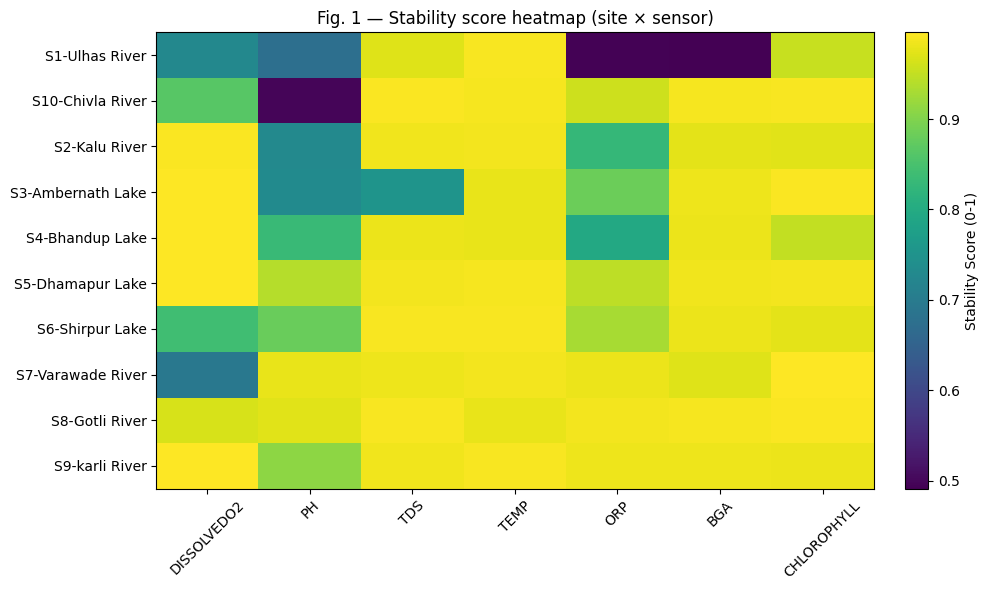

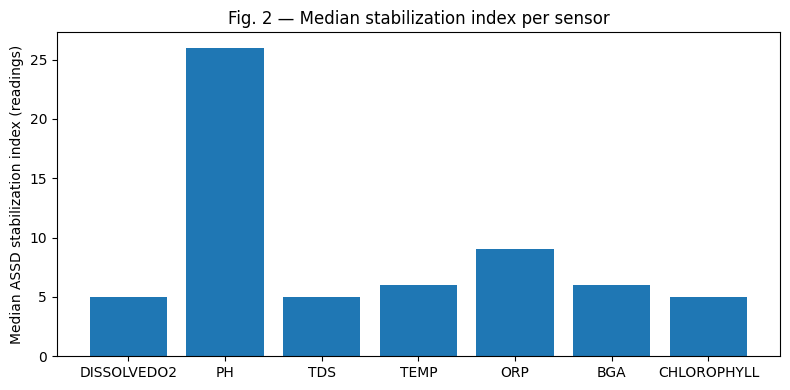

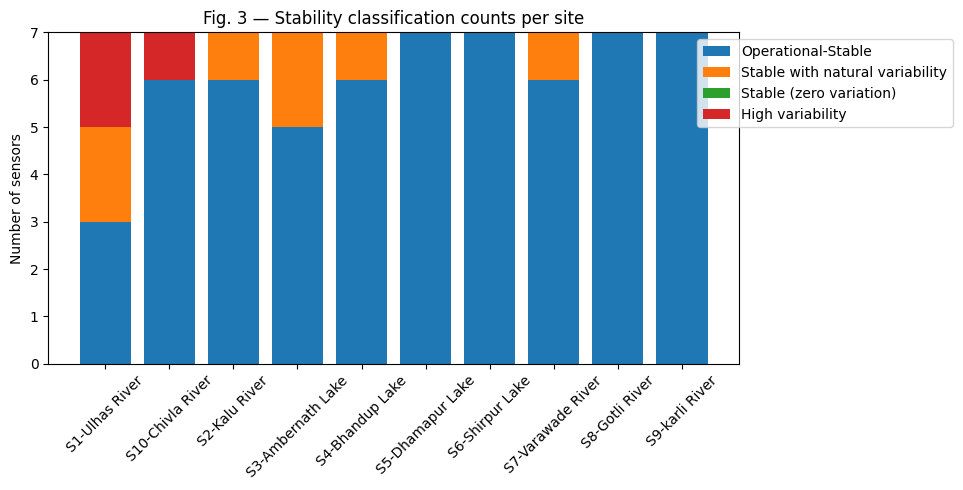

/tmp/ipython-input-1540633055.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rcv_data, labels=[s.upper() for s in sensors], showmeans=True)


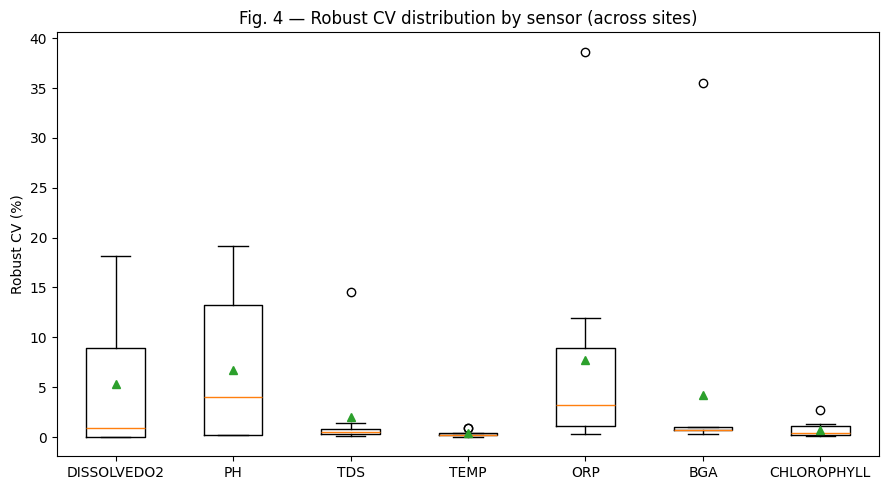

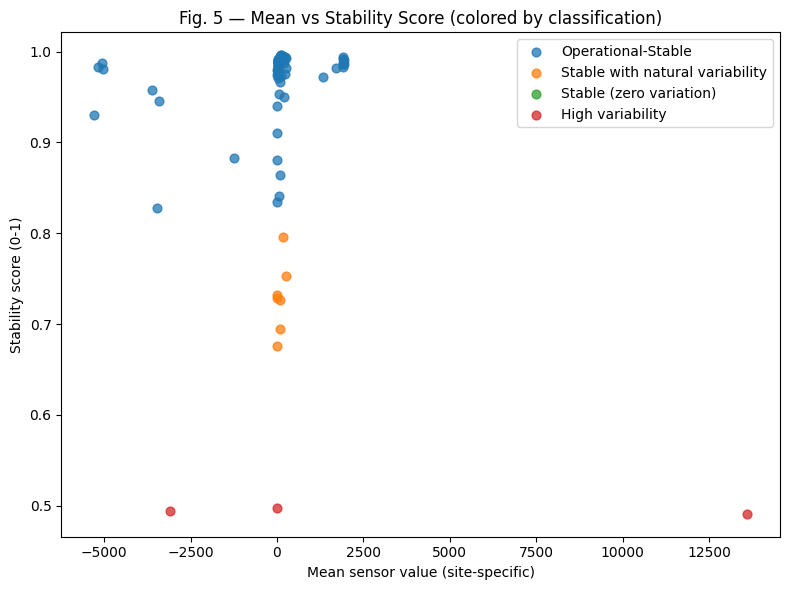

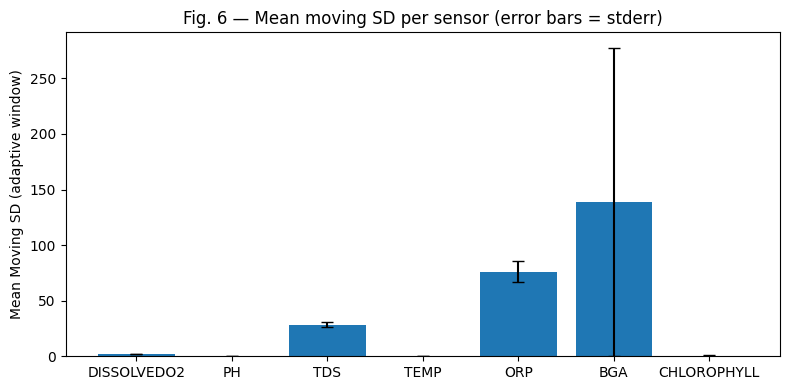

In [ ]:
# ====== Plotting script (matplotlib only) ======
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----- Edit path if needed -----
csv_path = "stability_all_sites_novel.csv"
df = pd.read_csv(csv_path)

# ensure consistent column names
df.columns = [c.lower().strip() for c in df.columns]

# sensors list (order for plots)
sensors = ["dissolvedo2","ph","tds","temp","orp","bga","chlorophyll"]

# pivot for heatmap: rows=sites, cols=sensors -> stability_score_0_1
heat = df.pivot(index="site", columns="sensor", values="stability_score_0_1").reindex(columns=sensors)
sites = heat.index.tolist()

# 1) Heatmap of stability score (sites x sensors)
plt.figure(figsize=(10,6))
im = plt.imshow(heat.values, aspect='auto', interpolation='nearest')
plt.colorbar(im, fraction=0.046, pad=0.04, label='Stability Score (0-1)')
plt.yticks(np.arange(len(sites)), sites)
plt.xticks(np.arange(len(sensors)), [s.upper() for s in sensors], rotation=45)
plt.title("Fig. 1 — Stability score heatmap (site × sensor)")
plt.tight_layout()
plt.savefig("fig1_stability_heatmap.png", dpi=300)
plt.show()

# 2) Median ASSD stabilization index per sensor (bar)
assd_med = df.groupby("sensor")["assd_stable_index"].median().reindex(sensors)
plt.figure(figsize=(8,4))
plt.bar([s.upper() for s in assd_med.index], assd_med.values)
plt.ylabel("Median ASSD stabilization index (readings)")
plt.title("Fig. 2 — Median stabilization index per sensor")
plt.tight_layout()
plt.savefig("fig2_assd_median.png", dpi=300)
plt.show()

# 3) Stacked bar: classification counts per site
# ensure classification values exist
class_order = ["Operational-Stable", "Stable with natural variability", "Stable (zero variation)", "High variability"]
site_counts = pd.crosstab(df['site'], df['classification']).reindex(index=sites, columns=class_order).fillna(0)
plt.figure(figsize=(10,5))
bottom = np.zeros(len(site_counts))
x = np.arange(len(site_counts))
for cls in class_order:
    vals = site_counts[cls].values
    plt.bar(x, vals, bottom=bottom, label=cls)
    bottom += vals
plt.xticks(x, site_counts.index, rotation=45)
plt.ylabel("Number of sensors")
plt.title("Fig. 3 — Stability classification counts per site")
plt.legend(loc='upper right', bbox_to_anchor=(1.32,1))
plt.tight_layout()
plt.savefig("fig3_classification_stacked.png", dpi=300, bbox_inches='tight')
plt.show()

# 4) Boxplot: Robust CV distribution by sensor
plt.figure(figsize=(9,5))
rcv_data = [df[df['sensor']==s]['robust_cv_%'].dropna().values for s in sensors]
plt.boxplot(rcv_data, labels=[s.upper() for s in sensors], showmeans=True)
plt.ylabel("Robust CV (%)")
plt.title("Fig. 4 — Robust CV distribution by sensor (across sites)")
plt.tight_layout()
plt.savefig("fig4_rcv_boxplot.png", dpi=300)
plt.show()

# 5) Scatter: mean value vs stability score (colored by classification)
# for clarity, plot one marker per row in df
plt.figure(figsize=(8,6))
classes = df['classification'].unique().tolist()
colors = ['tab:blue','tab:orange','tab:green','tab:red']
color_map = {c: colors[i%len(colors)] for i,c in enumerate(class_order)}
for cls in class_order:
    sub = df[df['classification']==cls]
    plt.scatter(sub['mean'], sub['stability_score_0_1'], alpha=0.75, label=cls, c=color_map[cls], s=40)
plt.xlabel("Mean sensor value (site-specific)")
plt.ylabel("Stability score (0-1)")
plt.title("Fig. 5 — Mean vs Stability Score (colored by classification)")
plt.legend()
plt.tight_layout()
plt.savefig("fig5_mean_vs_stability.png", dpi=300)
plt.show()

# 6) Bar chart: average moving SD per sensor (with std error)
msd = df.groupby("sensor")["moving_sd"].agg(['mean','std']).reindex(sensors)
plt.figure(figsize=(8,4))
means = msd['mean'].values
errs = msd['std'].values / np.sqrt(df['site'].nunique())  # rough stderr
plt.bar([s.upper() for s in msd.index], means, yerr=errs, capsize=4)
plt.ylabel("Mean Moving SD (adaptive window)")
plt.title("Fig. 6 — Mean moving SD per sensor (error bars = stderr)")
plt.tight_layout()
plt.savefig("fig6_moving_sd_bar.png", dpi=300)
plt.show()


Final graphs

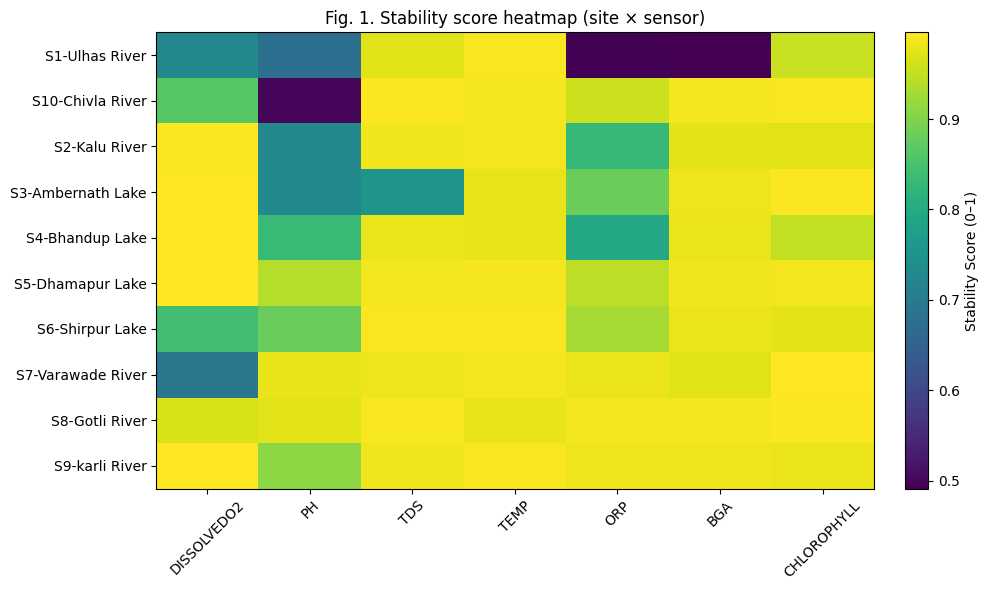

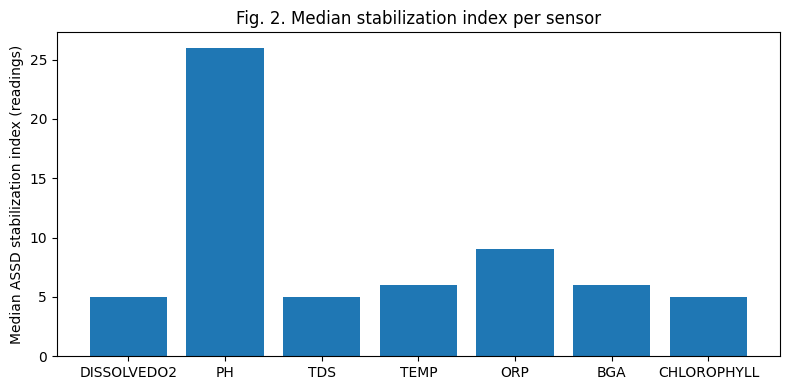

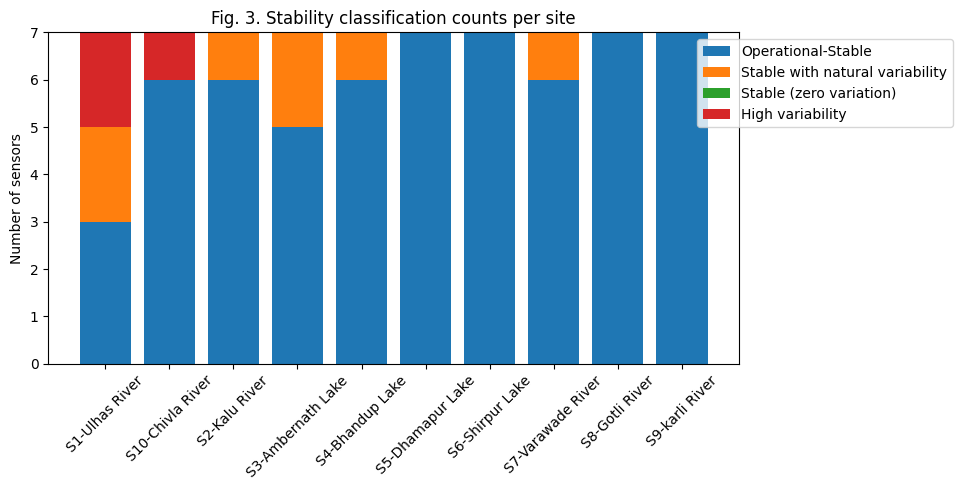

/tmp/ipython-input-3292519378.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rcv_data,


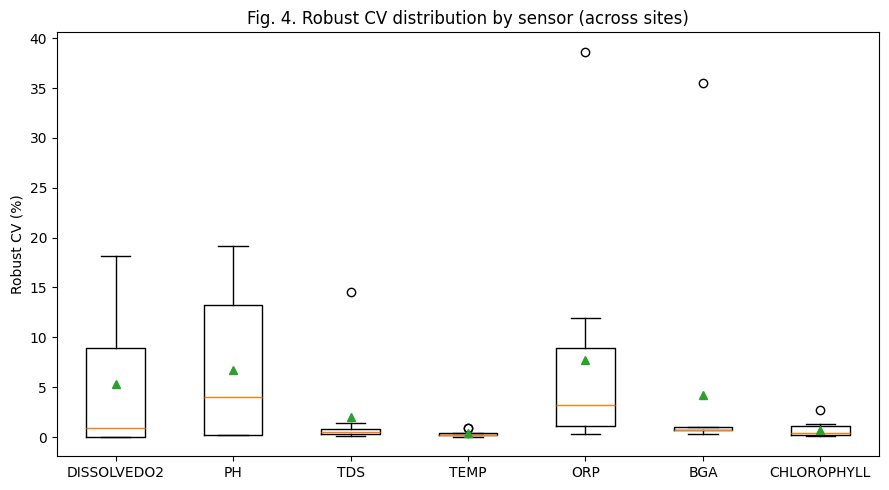

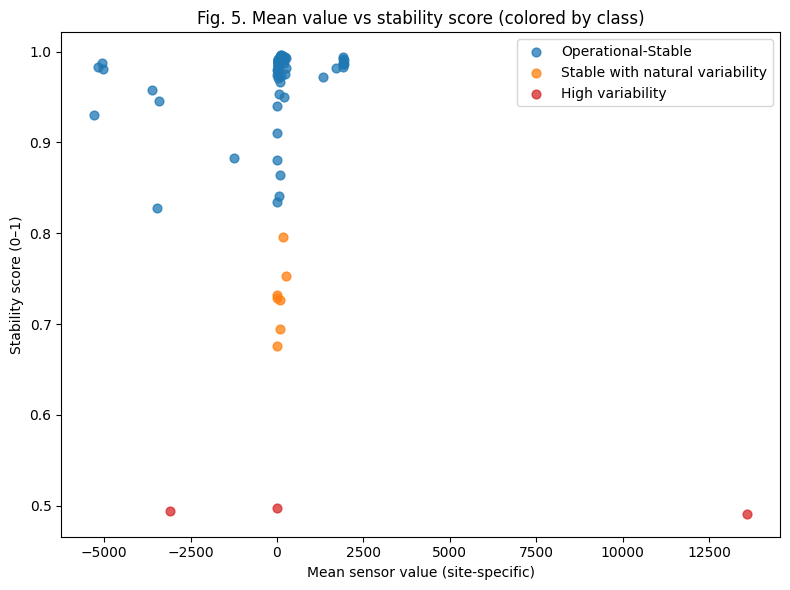

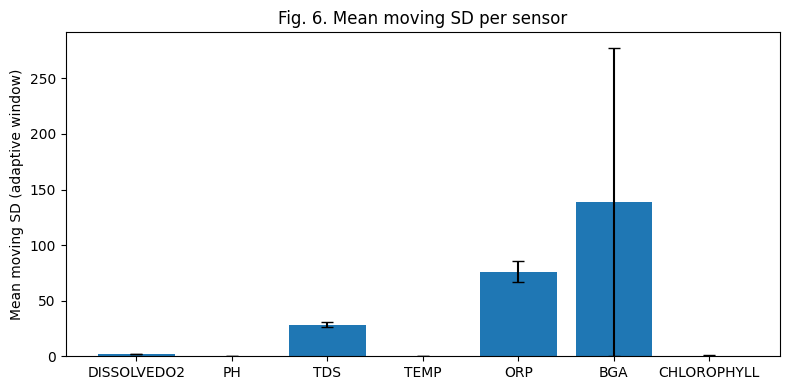

All figures generated and saved as PNG files.


In [ ]:
# ============================================
# Plotting script for stability_all_sites_novel.csv
# Generates Fig. 1–6 for the paper
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------- 0. Load data ---------
# Change the path if your CSV is somewhere else
csv_path = "stability_all_sites_novel.csv"
df = pd.read_csv(csv_path)

# Normalize column names to lowercase
df.columns = [c.lower().strip() for c in df.columns]

# --------- 1. Basic config ---------
# Order of sensors for all plots (no turbidity)
sensors = ["dissolvedo2", "ph", "tds", "temp", "orp", "bga", "chlorophyll"]

# Make sure 'sensor' and 'site' are treated as strings
df["sensor"] = df["sensor"].astype(str).str.lower()
df["site"] = df["site"].astype(str)

# Filter to only the sensors we care about (safety)
df = df[df["sensor"].isin(sensors)].copy()

# ========= Fig. 1 — Stability score heatmap (site × sensor) =========
# Pivot: rows = sites, columns = sensors, values = stability_score_0_1
heat = df.pivot(index="site", columns="sensor", values="stability_score_0_1")
# Reorder columns to the sensor list
heat = heat.reindex(columns=sensors)

sites = heat.index.tolist()

plt.figure(figsize=(10, 6))
im = plt.imshow(heat.values, aspect='auto', interpolation='nearest')
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Stability Score (0–1)')

plt.yticks(np.arange(len(sites)), sites)
plt.xticks(np.arange(len(sensors)), [s.upper() for s in sensors], rotation=45)
plt.title("Fig. 1. Stability score heatmap (site × sensor)")
plt.tight_layout()
plt.savefig("fig1_stability_heatmap.png", dpi=300)
plt.show()

# ========= Fig. 2 — Median stabilization index per sensor =========
assd_med = (
    df.groupby("sensor")["assd_stable_index"]
      .median()
      .reindex(sensors)
)

plt.figure(figsize=(8, 4))
plt.bar([s.upper() for s in assd_med.index], assd_med.values)
plt.ylabel("Median ASSD stabilization index (readings)")
plt.title("Fig. 2. Median stabilization index per sensor")
plt.tight_layout()
plt.savefig("fig2_assd_median.png", dpi=300)
plt.show()

# ========= Fig. 3 — Stability classification counts per site =========
class_order = [
    "Operational-Stable",
    "Stable with natural variability",
    "Stable (zero variation)",
    "High variability",
]

# ensure classification column exists and is string
df["classification"] = df["classification"].astype(str)

site_counts = pd.crosstab(df["site"], df["classification"])
# Reindex rows and columns so order is consistent, fill missing with 0
site_counts = (
    site_counts.reindex(index=sites, columns=class_order)
               .fillna(0)
)

plt.figure(figsize=(10, 5))
bottom = np.zeros(len(site_counts))
x = np.arange(len(site_counts))

for cls in class_order:
    if cls in site_counts.columns:
        vals = site_counts[cls].values
        plt.bar(x, vals, bottom=bottom, label=cls)
        bottom += vals

plt.xticks(x, site_counts.index, rotation=45)
plt.ylabel("Number of sensors")
plt.title("Fig. 3. Stability classification counts per site")
plt.legend(loc='upper right', bbox_to_anchor=(1.32, 1))
plt.tight_layout()
plt.savefig("fig3_classification_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

# ========= Fig. 4 — Robust CV distribution by sensor =========
plt.figure(figsize=(9, 5))

rcv_data = [
    df[df["sensor"] == s]["robust_cv_%"].dropna().values
    for s in sensors
]

plt.boxplot(rcv_data,
            labels=[s.upper() for s in sensors],
            showmeans=True)

plt.ylabel("Robust CV (%)")
plt.title("Fig. 4. Robust CV distribution by sensor (across sites)")
plt.tight_layout()
plt.savefig("fig4_rcv_boxplot.png", dpi=300)
plt.show()

# ========= Fig. 5 — Mean vs Stability Score (colored by classification) =========
plt.figure(figsize=(8, 6))

# Make sure we use a consistent color mapping
classes = [c for c in class_order if c in df["classification"].unique()]
base_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
color_map = {cls: base_colors[i % len(base_colors)] for i, cls in enumerate(class_order)}

for cls in class_order:
    sub = df[df["classification"] == cls]
    if len(sub) == 0:
        continue
    plt.scatter(
        sub["mean"], sub["stability_score_0_1"],
        alpha=0.75, label=cls,
        c=color_map[cls], s=40
    )

plt.xlabel("Mean sensor value (site-specific)")
plt.ylabel("Stability score (0–1)")
plt.title("Fig. 5. Mean value vs stability score (colored by class)")
plt.legend()
plt.tight_layout()
plt.savefig("fig5_mean_vs_stability.png", dpi=300)
plt.show()

# ========= Fig. 6 — Mean moving SD per sensor (adaptive window) =========
msd = (
    df.groupby("sensor")["moving_sd"]
      .agg(["mean", "std"])
      .reindex(sensors)
)

plt.figure(figsize=(8, 4))
means = msd["mean"].values
# rough standard error: std / sqrt(number of sites)
n_sites = df["site"].nunique()
errs = msd["std"].values / np.sqrt(n_sites if n_sites > 0 else 1)

plt.bar([s.upper() for s in msd.index], means, yerr=errs, capsize=4)
plt.ylabel("Mean moving SD (adaptive window)")
plt.title("Fig. 6. Mean moving SD per sensor")
plt.tight_layout()
plt.savefig("fig6_moving_sd_bar.png", dpi=300)
plt.show()

print("All figures generated and saved as PNG files.")
